In [40]:
import os
import re
import json
import pandas as pd
import numpy as np
from tqdm import tqdm
from datetime import datetime

import seaborn as sns
from matplotlib import pyplot as plt
from matplotlib.colors import BoundaryNorm
from matplotlib.colors import ListedColormap


from patsy import dmatrices
import bambi as bmb
import arviz as az
from scipy.stats import chi2
import statsmodels.api as sm
import matplotlib.pyplot as plt
from IPython.display import display
import statsmodels.formula.api as smf
from scipy.stats import chi2_contingency
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.outliers_influence import variance_inflation_factor

from util import *

sns.set_palette('colorblind')

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

### initialise vars

In [2]:
msnbc_urls = [
    "https://www.instagram.com/msnbc/reel/DQz6GiKkqD-/",
    "https://www.instagram.com/msnbc/reel/DQzvigyiu3R/",
    "https://www.instagram.com/msnbc/reel/DQzaxBeisq2/",
    "https://www.instagram.com/msnbc/reel/DQzOhJyil7B/",
    "https://www.instagram.com/msnbc/reel/DQx_MsXDdqz/",
    "https://www.instagram.com/reel/DQx6d6TDFvD/",
    "https://www.instagram.com/reel/DQxz17nkXAu/",
    "https://www.instagram.com/reel/DQxxwsjEQxy/",
    "https://www.instagram.com/reel/DQxf5uvERD0/",
    "https://www.instagram.com/reel/DQxc21kkqwR/",
]

huffpost_urls = [
    "https://www.instagram.com/huffpost/reel/DQzSuMQARR0/",
    "https://www.instagram.com/huffpost/p/DQxLW-PEns-/",
    "https://www.instagram.com/huffpost/reel/DQxARFuAbt-/",
    "https://www.instagram.com/huffpost/reel/DQw6Qa_kWgY/",
    "https://www.instagram.com/huffpost/reel/DQw5_xHkWod/",
    "https://www.instagram.com/huffpost/reel/DQwbCxQjQNQ/",
    "https://www.instagram.com/huffpost/p/DQu2w59E9t-/",
    "https://www.instagram.com/huffpost/reel/DQvEm2FDCmz/",
    "https://www.instagram.com/huffpost/p/DQuw7U7D322/",
    "https://www.instagram.com/p/DQujjUrk61E/"
]

cnn_urls = [
    "https://www.instagram.com/reel/DQ0VgDjjx7K/",
    # "https://www.instagram.com/p/DQ0LWj6jue3/",
    "https://www.instagram.com/reel/DQz7vqJiEUj/",
    "https://www.instagram.com/reel/DQznNr7gp1F/",
    "https://www.instagram.com/reel/DQzgXgPgPmN/",
    "https://www.instagram.com/reel/DQzNYM8ARN3/",
    "https://www.instagram.com/reel/DQzEp0pChCY/",
    "https://www.instagram.com/reel/DQy-AdiCcH_/",
    "https://www.instagram.com/reel/DQyzpQVjga4/",
    "https://www.instagram.com/reel/DQypWvmDoge/"
]

washingtonpost_urls = [
    "https://www.instagram.com/washingtonpost/p/DQ0JgL9DqcC/",
    "https://www.instagram.com/washingtonpost/p/DQz7wRODMr8/",
    "https://www.instagram.com/washingtonpost/p/DQzuD3fFJcu/",
    "https://www.instagram.com/washingtonpost/reel/DQzh-t0DSAJ/",
    "https://www.instagram.com/washingtonpost/reel/DQzgTDHAcKl/",
    "https://www.instagram.com/p/DQzZihPDiQv/",
    "https://www.instagram.com/reel/DQzSo12D1fJ/",
    "https://www.instagram.com/reel/DQzLtq3ARq3/",
    "https://www.instagram.com/p/DQxxk6BDvZh/",
    "https://www.instagram.com/p/DQxqaCpDcHC/"
]

forbes_urls = [
    "https://www.instagram.com/forbes/p/DQ0Ck-lgUxt/",
    "https://www.instagram.com/forbes/p/DQz0444AWAd/",
    "https://www.instagram.com/forbes/p/DQzgP9_gcjC/",
    "https://www.instagram.com/p/DQzUOiGAblX/",
    "https://www.instagram.com/p/DQzLpqJDxMD/",
    "https://www.instagram.com/p/DQzFWzxkT-c/",
    "https://www.instagram.com/p/DQxdypCDPF2/",
    "https://www.instagram.com/p/DQxOpmbkn_b/",
    "https://www.instagram.com/p/DQxFjBJj4gS/",
    "https://www.instagram.com/p/DQxElAzD6aK/"
]

thehill_urls = [
    "https://www.instagram.com/thehill/p/DQzfVDcE3YB/",
    "https://www.instagram.com/thehill/p/DQxg1ufkeqR/",
    "https://www.instagram.com/thehill/reel/DQxViLFEdQ5/",
    "https://www.instagram.com/thehill/p/DQw1LZxEwrn/",
    "https://www.instagram.com/thehill/p/DQwgkZxD2Ug/",
    "https://www.instagram.com/thehill/reel/DQvAK9hEeWU/",
    "https://www.instagram.com/thehill/p/DQunQLokn-7/",
    "https://www.instagram.com/thehill/reel/DQuNa5zEeiR/",
    "https://www.instagram.com/thehill/p/DQt9lxsjumG/",
    "https://www.instagram.com/reel/DQrpC35EXqn/"
]

washingtontimes_urls = [
    "https://www.instagram.com/washtimes/p/DQz0CxJExjr/",
    "https://www.instagram.com/washtimes/p/DQzcWsGkg8C/",
    "https://www.instagram.com/washtimes/p/DQxHICQE_29/",
    "https://www.instagram.com/washtimes/p/DQw_V8sE6ZH/",
    "https://www.instagram.com/washtimes/p/DQw3jz6k0L6/",
    "https://www.instagram.com/washtimes/p/DQwvq-dktiv/",
    "https://www.instagram.com/washtimes/p/DQwn4b2EzCR/",
    "https://www.instagram.com/washtimes/p/DQwgGZ2jQck/",
    "https://www.instagram.com/washtimes/p/DQvCB1iEwBa/",
    "https://www.instagram.com/washtimes/reel/DQu5zA1CL3U/"
]

nypost_urls = [
    "https://www.instagram.com/p/DQ0Jd_SAc4Z/",
    "https://www.instagram.com/p/DQ0GBAngWyx/",
    "https://www.instagram.com/reel/DQ0ETkoDtLN/",
    "https://www.instagram.com/p/DQ0ClEugU1r/",
    "https://www.instagram.com/p/DQz_JRkAWr9/",
    "https://www.instagram.com/reel/DQz9kQIDZOc/",
    "https://www.instagram.com/p/DQz70tPAQTn/",
    "https://www.instagram.com/p/DQz4Y1Xgadc/",
    "https://www.instagram.com/reel/DQz2rWGEkpe/",
    "https://www.instagram.com/p/DQz09vagSe1/"
]

foxnews_urls = [
    "https://www.instagram.com/reel/DQ0V_qAEfwE/",
    "https://www.instagram.com/reel/DQ0UdiODE-2/",
    "https://www.instagram.com/reel/DQ0UNIZD3rv/",
    "https://www.instagram.com/reel/DQ0OfgWAswZ/",
    "https://www.instagram.com/reel/DQ0OAwCk91U/",
    "https://www.instagram.com/reel/DQ0GaXEjofE/",
    "https://www.instagram.com/reel/DQ0ClztkmYz/",
    "https://www.instagram.com/p/DQ0AYUTkvh4/",
    "https://www.instagram.com/p/DQz8ZTUjJ4s/",
    "https://www.instagram.com/reel/DQz8UW2j4TQ/"
]

breitbart_urls = [
    "https://www.instagram.com/p/DQ0P_UtDFLj/",
    "https://www.instagram.com/p/DQ0ImR1DaM0/",
    "https://www.instagram.com/p/DQz28XJkuQV/",
    "https://www.instagram.com/p/DQzkN12CUZQ/",
    "https://www.instagram.com/reel/DQzXuPOkgOo/",
    "https://www.instagram.com/p/DQzR5CjkQxS/",
    "https://www.instagram.com/p/DQzJCenDSPC/",
    "https://www.instagram.com/p/DQy1VfcETEi/",
    "https://www.instagram.com/reel/DQxZ3LCkvgh/",
    "https://www.instagram.com/p/DQxfi8JjVGb/"
]

news_urls = {
    'msnbc': msnbc_urls,
    'huffpost': huffpost_urls,
    'cnn': cnn_urls,
    'washingtonpost': washingtonpost_urls,
    'forbes': forbes_urls,
    'thehill': thehill_urls,
    'washingtontimes': washingtontimes_urls,
    'nypost': nypost_urls,
    'foxnews': foxnews_urls,
    'breitbart': breitbart_urls
}

In [3]:
peacock_urls = [
    'https://www.instagram.com/peacock/reel/DSEC7pojf3H/',
    'https://www.instagram.com/peacock/reel/DSEFSQJAGeV/',
    'https://www.instagram.com/peacock/p/DSD45vFgDBd/',
    'https://www.instagram.com/peacock/reel/DSDUvgsgLqk/',
    'https://www.instagram.com/belairpeacock/reel/DSDOHnBCS0t/',
    'https://www.instagram.com/nbc/reel/DSDOHj2kr00/',
    'https://www.instagram.com/spotify/reel/DSDN0oCDkGb/',
    'https://www.instagram.com/peacock/p/DSDAUdIgDUw/',
    'https://www.instagram.com/peacock/reel/DSBm_S8gC1p/',
    'https://www.instagram.com/peacock/reel/DSBZZEcgL4D/',
]

nytcooking_urls = [
    'https://www.instagram.com/nytcooking/reel/DSD_gy1DcX5/',
    'https://www.instagram.com/nytcooking/p/DSDwcgkk1qn/',
    'https://www.instagram.com/nytcooking/p/DSDitvpAZUH/',
    'https://www.instagram.com/nytcooking/p/DSDb1UoknQg/',
    'https://www.instagram.com/nytcooking/p/DSDU8zokpV3/',
    'https://www.instagram.com/nytcooking/p/DSDOaPWk4bv/',
    'https://www.instagram.com/nytcooking/p/DSDSO3Fkwax/',
    'https://www.instagram.com/nytcooking/reel/DSDNChjDjIB/',
    'https://www.instagram.com/nytcooking/p/DSC_QAgks4q/',
    'https://www.instagram.com/nytcooking/p/DSDBAbzjifA/',
]

espn_urls = [
    'https://www.instagram.com/espn/reel/DSEgVgeAPWE/',
    'https://www.instagram.com/espncfb/p/DSEWMX5jGnh/',
    'https://www.instagram.com/espn/reel/DSEVBjZAOdU/',
    'https://www.instagram.com/espn/p/DSEOlBoDCRb/',
    'https://www.instagram.com/espn/p/DSEMouEjLXr/',
    'https://www.instagram.com/espn/p/DSELB0fjEiG/',
    'https://www.instagram.com/espn/p/DSEIW-zjJXe/',
    'https://www.instagram.com/espn/p/DSD6pTxgdJv/',
    'https://www.instagram.com/espn/p/DSDrfEyDxs-/',
    'https://www.instagram.com/espn/p/DSDjBkeEiVo/',
]

catloversclub_urls = [
    'https://www.instagram.com/catloversclub/reel/DSEn813Eo5Q/',
    'https://www.instagram.com/catloversclub/reel/DSEHOC8kufg/',
    'https://www.instagram.com/catloversclub/p/DSDzLhlkniQ/',
    'https://www.instagram.com/catloversclub/p/DSC60BKkrYV/',
    'https://www.instagram.com/catloversclub/reel/DSBk9RQEmtF/',
    'https://www.instagram.com/catloversclub/p/DSBQuBCEg6f/',
    'https://www.instagram.com/catloversclub/p/DSARqDnEhPJ/',
    'https://www.instagram.com/catloversclub/p/DR_mqpKEr01/',
    'https://www.instagram.com/catloversclub/reel/DR_fCEnEmtA/',
    'https://www.instagram.com/catloversclub/p/DR-_MPRkurr/',
]

thedogist_urls = [
    'https://www.instagram.com/thedogist/p/DSDe6u8kS6O/',
    'https://www.instagram.com/thedogist/reel/DR-aHhzkXgF/',
    'https://www.instagram.com/thedogist/reel/DR72mfKEedE/',
    'https://www.instagram.com/empirestatebldg/reel/DR7aTBTkebB/',
    'https://www.instagram.com/thedogist/p/DR5O3P_jycm/',
    'https://www.instagram.com/thedogist/reel/DR4mTwyESDm/',
    'https://www.instagram.com/thedogist/reel/DR2VEONkdPT/',
    'https://www.instagram.com/thedogist/reel/DRw-IF6EaT_/',
    'https://www.instagram.com/thedogist/p/DRqGWbcEVvW/',
    'https://www.instagram.com/thedogist/reel/DRnCa95EcVk/',
]

thegradecricketer = [
    'https://www.instagram.com/thegradecricketer/reel/DSEuOIXEsI6/',
    'https://www.instagram.com/thegradecricketer/reel/DSERcMKEs-k/',
    'https://www.instagram.com/thegradecricketer/reel/DSEC3JekvxZ/',
    'https://www.instagram.com/thegradecricketer/reel/DSCJfZ8jKrQ/',
    'https://www.instagram.com/kayosports/reel/DSB-wRmE6MH/',
    'https://www.instagram.com/triplemcricket/reel/DR_3mtdjCre/',
    'https://www.instagram.com/thegradecricketer/reel/DR_CMYYku_p/',
    'https://www.instagram.com/thegradecricketer/reel/DR9nU3FkhGV/',
    'https://www.instagram.com/thegradecricketer/reel/DR7tgNXgCeL/',
    'https://www.instagram.com/thegradecricketer/reel/DR5bFbrgFP0/',
]

pbsfood_urls = [
    'https://www.instagram.com/pbsfood/reel/DSC5fCjiBkw/',
    'https://www.instagram.com/pbsfood/p/DSAwJ9ZjgfK/',
    'https://www.instagram.com/pbsfood/p/DR99nxribK5/',
    'https://www.instagram.com/pbssocal/reel/DR2_SXGlN-b/',
    'https://www.instagram.com/pbsfood/p/DR2tagbj4NN/',
    'https://www.instagram.com/pbsfood/reel/DRzxYwWFLrA/',
    'https://www.instagram.com/pbsfood/p/DRr1KVSDQDY/',
    'https://www.instagram.com/pbsfood/p/DRmrnTCj0Uc/',
    'https://www.instagram.com/pbsfood/reel/DRkSd-jAfYR/',
    'https://www.instagram.com/pbsfood/p/DRkATf0DWKW/',
]

hulu_urls = [
    'https://www.instagram.com/hulu/reel/DSD-0GpEVyJ/',
    'https://www.instagram.com/hulu/reel/DSDb1_QCpwm/',
    'https://www.instagram.com/hulu/p/DSDPdCDja0P/',
    'https://www.instagram.com/hulu/reel/DSDAUFlkyrO/',
    'https://www.instagram.com/percyseries/reel/DSDNXoPjue0/',
    'https://www.instagram.com/freeform/reel/DSAz8SxDsaI/',
    'https://www.instagram.com/hulu/p/DSBtohckS3R/',
    'https://www.instagram.com/kumailn/reel/DSBN7auEbAo/',
    'https://www.instagram.com/hulu/reel/DSBAnzeFae5/',
    'https://www.instagram.com/getspectrum/reel/DSA91c8EeIY/',
]

ladbible_urls = [
    'https://www.instagram.com/ladbible/p/DSCrwGuDxUR/',
    'https://www.instagram.com/ladbible/reel/DSCoNYQDAK-/',
    'https://www.instagram.com/ladbible/p/DSCd_wJABTo/',
    'https://www.instagram.com/ladbible/p/DSA3Yh7ACwc/',
    'https://www.instagram.com/sportbible/p/DSAzKDHjI_T/',
    'https://www.instagram.com/sportbible/p/DSAwJA8kctO/',
    'https://www.instagram.com/ladbible/reel/DSApUwzlTf_/',
    'https://www.instagram.com/ladbible/p/DSAic0ZEhfR/',
    'https://www.instagram.com/ladbible/p/DSAYaLiE0TC/',
    'https://www.instagram.com/ladbible/p/DSAG9sXk1Fn/',
]

accesshollywood_urls = [
    'https://www.instagram.com/accesshollywood/reel/DSEBiASCUPH/',
    'https://www.instagram.com/accesshollywood/p/DSD1KHYkXtU/',
    'https://www.instagram.com/accesshollywood/reel/DSDirU6EkO2/',
    'https://www.instagram.com/accesshollywood/p/DSDU9GlDmn4/',
    'https://www.instagram.com/accesshollywood/reel/DSDKXfBCjPl/',
    'https://www.instagram.com/accesshollywood/p/DSC5lsdkySq/',
    'https://www.instagram.com/accesshollywood/reel/DSB-0hjkQNx/',
    'https://www.instagram.com/accesshollywood/reel/DSBnCAXiIL3/',
    'https://www.instagram.com/accesshollywood/reel/DSBZVIJjRta/',
    'https://www.instagram.com/accesshollywood/p/DSBAeqRk4is/',
]

nonnews_urls = {
    'peacock': peacock_urls,
    'nytcooking': nytcooking_urls,
    'espn': espn_urls,
    'catloversclub': catloversclub_urls,
    'thedogist': thedogist_urls,
    'thegradecricketer': thegradecricketer,
    'pbsfood': pbsfood_urls,
    'hulu': hulu_urls,
    'ladbible': ladbible_urls,
    'accesshollywood': accesshollywood_urls
}

In [4]:
all_crawls = ['male_dem_ny_1', 'male_dem_texas_1',
              'male_rep_ny_1', 'male_rep_texas_1',
              'female_dem_ny_1', 'female_dem_texas_1',
              'female_rep_ny_1', 'female_rep_texas_1']

file_path = '/Users/brahmaninutakki/saarland/insta_comments/saved_data/new'

In [5]:
news_merged_filepath = '/Users/brahmaninutakki/saarland/insta_comments/saved_data/merged_data_news_comments.csv'
nonnews_merged_filepath = '/Users/brahmaninutakki/saarland/insta_comments/saved_data/merged_data_nonnews_comments.csv'

In [6]:
news_df = pd.read_csv(news_merged_filepath)
nonnews_df = pd.read_csv(nonnews_merged_filepath) 

In [7]:
pat = re.compile(
    r'(?ms)^'
    r'(?P<username>[A-Za-z0-9._]+)\n'
    r'(?:\s*(?:Edited|[•·])\s*\n)*'
    r'\s*(?P<num>\d+)\s*(?P<unit>[dw])\s*\n'
    r'(?P<text>.*?)(?=^([A-Za-z0-9._]+)\n(?:\s*(?:Edited|[•·])\s*\n)*\s*\d+\s*[dw]\s*\n|\Z)'
)

for caption in news_df['caption'].tolist():
    if pd.notna(caption):
        m = pat.search(caption)

news_df['caption_text'] = news_df['caption'].apply(lambda x: pat.search(x).groupdict().get('text') if pd.notna(x) else None)

In [8]:
pat = re.compile(
    r'(?ms)^'
    r'(?P<username>[A-Za-z0-9._]+)\n'
    r'(?:\s*(?:Edited|[•·])\s*\n)*'
    r'\s*(?P<num>\d+)\s*(?P<unit>[dw])\s*\n'
    r'(?P<text>.*?)(?=^([A-Za-z0-9._]+)\n(?:\s*(?:Edited|[•·])\s*\n)*\s*\d+\s*[dw]\s*\n|\Z)'
)

for caption in nonnews_df['caption'].tolist():
    if pd.notna(caption):
        m = pat.search(caption)

nonnews_df['caption_text'] = nonnews_df['caption'].apply(lambda x: pat.search(x).groupdict().get('text') if pd.notna(x) else None)

In [9]:
news_df.shape, nonnews_df.shape

((1279, 14), (1367, 14))

In [10]:
news_df.drop(columns=['caption'], inplace=True)
nonnews_df.drop(columns=['caption'], inplace=True)

In [11]:
nonnews_df[['account', 'urlid', 'comment_num']].duplicated().sum()

np.int64(330)

In [12]:
keys = ['account', 'urlid', 'comment_num']

news_df = (
    news_df
    .groupby(keys, sort=False, as_index=False)
    .agg(lambda s: s.dropna().iloc[0] if s.notna().any() else np.nan)
)

news_df[keys].duplicated().sum()

np.int64(0)

In [13]:
keys = ['account', 'urlid', 'comment_num']

nonnews_df = (
    nonnews_df
    .groupby(keys, sort=False, as_index=False)
    .agg(lambda s: s.dropna().iloc[0] if s.notna().any() else np.nan)
)

nonnews_df[keys].duplicated().sum()

np.int64(0)

In [14]:
news_df.shape, nonnews_df.shape

((980, 13), (1037, 13))

### plotting

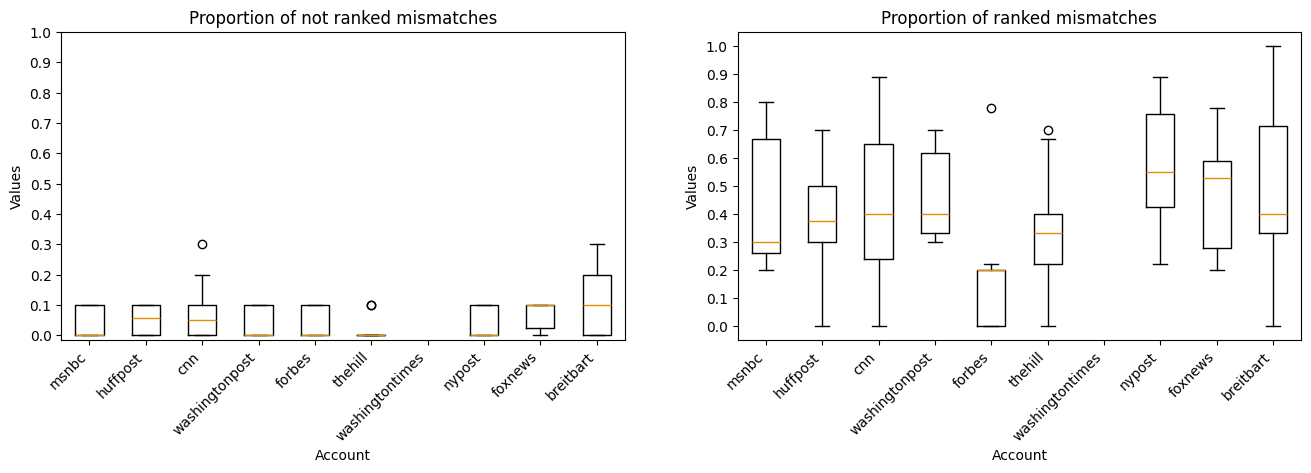

In [15]:
flag = 'news'

if flag == 'news':
    plot_df = news_df.copy()
    plot_urls = news_urls.copy()
elif flag == 'nonnews':
    plot_df = nonnews_df.copy()
    plot_urls = nonnews_urls.copy() 
else:
    raise(KeyError)

crawl1 = 'male_dem_ny_1'
crawl2 = 'female_rep_ny_1'

temp_df = plot_df.copy()
account_fprops_no_rank, account_fprops_rank, temp_df = compute_fprops(crawl1, crawl2, temp_df, plot_urls)


accounts = list(account_fprops_no_rank.keys())
values_no_rank = [account_fprops_no_rank[acc] for acc in accounts]
values_rank = [account_fprops_rank[acc] for acc in accounts]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4))

ax1.boxplot(values_no_rank, tick_labels=accounts)
ax1.set_title("Proportion of not ranked mismatches")
ax1.set_xlabel("Account")
ax1.set_ylabel("Values")
ax1.set_xticks(range(1, 11))
ax1.set_xticklabels(accounts, rotation=45, ha='right')
ax1.set_yticks(np.arange(0, 1.1, 0.1))

ax2.boxplot(values_rank, tick_labels=accounts)
ax2.set_title("Proportion of ranked mismatches")
ax2.set_xlabel("Account")
ax2.set_ylabel("Values")
ax2.set_xticks(range(1, 11))
ax2.set_xticklabels(accounts, rotation=45, ha='right')
ax2.set_yticks(np.arange(0, 1.1, 0.1))

plt.show()

In [16]:
flag = 'news'

if flag == 'news':
    plot_df = news_df.copy()
    plot_urls = news_urls.copy()
elif flag == 'nonnews':
    plot_df = nonnews_df.copy()
    plot_urls = nonnews_urls.copy() 
else:
    raise(KeyError)

mismatch_no_rank, mismatch_rank = {}, {}

for crawl1 in all_crawls:
    mismatch_no_rank[crawl1] = {}
    mismatch_rank[crawl1] = {}
    for crawl2 in all_crawls:
        mod_df = plot_df.copy()
        _, _, mod_df = compute_fprops(crawl1, crawl2, mod_df, plot_urls)

        temp_df = mod_df[mod_df['comment_num'] == 0]
        # mismatch_no_rank[crawl1][crawl2] = temp_df['fcount_no_rank'].sum() / temp_df['ftrials_no_rank'].sum()
        # mismatch_rank[crawl1][crawl2] = temp_df['fcount_rank'].sum() / temp_df['ftrials_rank'].sum()
        mismatch_no_rank[crawl1][crawl2] = (temp_df['fcount_no_rank'] / temp_df['ftrials_no_rank']).mean()
        mismatch_rank[crawl1][crawl2] = (temp_df['fcount_rank'] / temp_df['ftrials_rank']).mean()

news_mismatch_rank_df = pd.DataFrame.from_dict(mismatch_rank, orient="index")
news_mismatch_no_rank_df = pd.DataFrame.from_dict(mismatch_no_rank, orient="index")

news_mismatch_no_rank_df.rename(columns={
    'male_dem_ny_1': 'Male_Dem_NY',
    'male_dem_texas_1': 'Male_Dem_TX',
    'male_rep_ny_1': 'Male_Rep_NY',
    'male_rep_texas_1': 'Male_Rep_TX',
    'female_dem_ny_1': 'Female_Dem_NY',
    'female_dem_texas_1': 'Female_Dem_TX',
    'female_rep_ny_1': 'Female_Rep_NY',
    'female_rep_texas_1': 'Female_Rep_TX',
}, inplace=True)

news_mismatch_no_rank_df.rename(index={
    'male_dem_ny_1': 'Male_Dem_NY',
    'male_dem_texas_1': 'Male_Dem_TX',
    'male_rep_ny_1': 'Male_Rep_NY',
    'male_rep_texas_1': 'Male_Rep_TX',
    'female_dem_ny_1': 'Female_Dem_NY',
    'female_dem_texas_1': 'Female_Dem_TX',
    'female_rep_ny_1': 'Female_Rep_NY',
    'female_rep_texas_1': 'Female_Rep_TX',
}, inplace=True)

news_mismatch_rank_df.rename(columns={
    'male_dem_ny_1': 'Male_Dem_NY',
    'male_dem_texas_1': 'Male_Dem_Texas',
    'male_rep_ny_1': 'Male_Rep_NY',
    'male_rep_texas_1': 'Male_Rep_Texas',
    'female_dem_ny_1': 'Female_Dem_NY',
    'female_dem_texas_1': 'Female_Dem_Texas',
    'female_rep_ny_1': 'Female_Rep_NY',
    'female_rep_texas_1': 'Female_Rep_Texas',
}, inplace=True)

news_mismatch_rank_df.rename(index={
    'male_dem_ny_1': 'Male_Dem_NY',
    'male_dem_texas_1': 'Male_Dem_Texas',
    'male_rep_ny_1': 'Male_Rep_NY',
    'male_rep_texas_1': 'Male_Rep_Texas',
    'female_dem_ny_1': 'Female_Dem_NY',
    'female_dem_texas_1': 'Female_Dem_Texas',
    'female_rep_ny_1': 'Female_Rep_NY',
    'female_rep_texas_1': 'Female_Rep_Texas',
}, inplace=True)


# fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)

# hm0 = sns.heatmap(
#     news_mismatch_no_rank_df, annot=True, fmt=".2f",
#     cmap="Reds", vmin=0, vmax=1,
#     ax=axes[0], cbar=False
# )
# axes[0].set_title(f"Average mismatch proportion for {flag} accounts across all pairs of crawls")

# hm1 = sns.heatmap(
#     news_mismatch_rank_df, annot=True, fmt=".2f",
#     cmap="Reds", vmin=0, vmax=1,
#     ax=axes[1], cbar=False
# )
# axes[1].set_title(f"Rank mismatch: {flag}")

# cbar = fig.colorbar(
#     hm0.collections[0],
#     ax=axes,
#     orientation="vertical",
#     location="left", 
#     pad=0.02,
#     fraction=0.06,
#     aspect=40
# )
# cbar.ax.xaxis.set_ticks_position("top")
# cbar.ax.xaxis.set_label_position("top")

In [ ]:
flag = 'nonnews'

if flag == 'news':
    plot_df = news_df.copy()
    plot_urls = news_urls.copy()
elif flag == 'nonnews':
    plot_df = nonnews_df.copy()
    plot_urls = nonnews_urls.copy() 
else:
    raise(KeyError)

mismatch_no_rank, mismatch_rank = {}, {}

for crawl1 in all_crawls:
    mismatch_no_rank[crawl1] = {}
    mismatch_rank[crawl1] = {}
    for crawl2 in all_crawls:
        mod_df = plot_df.copy()
        _, _, mod_df = compute_fprops(crawl1, crawl2, mod_df, plot_urls)

        temp_df = mod_df[mod_df['comment_num'] == 0]
        # mismatch_no_rank[crawl1][crawl2] = temp_df['fcount_no_rank'].sum() / temp_df['ftrials_no_rank'].sum()
        # mismatch_rank[crawl1][crawl2] = temp_df['fcount_rank'].sum() / temp_df['ftrials_rank'].sum()
        mismatch_no_rank[crawl1][crawl2] = (temp_df['fcount_no_rank'] / temp_df['ftrials_no_rank']).mean()
        mismatch_rank[crawl1][crawl2] = (temp_df['fcount_rank'] / temp_df['ftrials_rank']).mean()

nonnews_mismatch_rank_df = pd.DataFrame.from_dict(mismatch_rank, orient="index")
nonnews_mismatch_no_rank_df = pd.DataFrame.from_dict(mismatch_no_rank, orient="index")

nonnews_mismatch_no_rank_df.rename(columns={
    'male_dem_ny_1': 'Male_Dem_NY',
    'male_dem_texas_1': 'Male_Dem_TX',
    'male_rep_ny_1': 'Male_Rep_NY',
    'male_rep_texas_1': 'Male_Rep_TX',
    'female_dem_ny_1': 'Female_Dem_NY',
    'female_dem_texas_1': 'Female_Dem_TX',
    'female_rep_ny_1': 'Female_Rep_NY',
    'female_rep_texas_1': 'Female_Rep_TX',
}, inplace=True)

nonnews_mismatch_no_rank_df.rename(index={
    'male_dem_ny_1': 'Male_Dem_NY',
    'male_dem_texas_1': 'Male_Dem_TX',
    'male_rep_ny_1': 'Male_Rep_NY',
    'male_rep_texas_1': 'Male_Rep_TX',
    'female_dem_ny_1': 'Female_Dem_NY',
    'female_dem_texas_1': 'Female_Dem_TX',
    'female_rep_ny_1': 'Female_Rep_NY',
    'female_rep_texas_1': 'Female_Rep_TX',
}, inplace=True)

nonnews_mismatch_rank_df.rename(columns={
    'male_dem_ny_1': 'Male_Dem_NY',
    'male_dem_texas_1': 'Male_Dem_Texas',
    'male_rep_ny_1': 'Male_Rep_NY',
    'male_rep_texas_1': 'Male_Rep_Texas',
    'female_dem_ny_1': 'Female_Dem_NY',
    'female_dem_texas_1': 'Female_Dem_Texas',
    'female_rep_ny_1': 'Female_Rep_NY',
    'female_rep_texas_1': 'Female_Rep_Texas',
}, inplace=True)

nonnews_mismatch_rank_df.rename(index={
    'male_dem_ny_1': 'Male_Dem_NY',
    'male_dem_texas_1': 'Male_Dem_Texas',
    'male_rep_ny_1': 'Male_Rep_NY',
    'male_rep_texas_1': 'Male_Rep_Texas',
    'female_dem_ny_1': 'Female_Dem_NY',
    'female_dem_texas_1': 'Female_Dem_Texas',
    'female_rep_ny_1': 'Female_Rep_NY',
    'female_rep_texas_1': 'Female_Rep_Texas',
}, inplace=True)


# fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)

# hm0 = sns.heatmap(
#     nonnews_mismatch_no_rank_df, annot=True, fmt=".2f",
#     cmap="Reds", vmin=0, vmax=1,
#     ax=axes[0], cbar=False
# )
# axes[0].set_title(f"Average mismatch proportion for {flag} accounts across all pairs of crawls")

# hm1 = sns.heatmap(
#     nonnews_mismatch_rank_df, annot=True, fmt=".2f",
#     cmap="Reds", vmin=0, vmax=1,
#     ax=axes[1], cbar=False
# )
# axes[1].set_title(f"Rank mismatch: {flag}")

# cbar = fig.colorbar(
#     hm0.collections[0],
#     ax=axes,
#     orientation="vertical",
#     location="left", 
#     pad=0.02,
#     fraction=0.06,
#     aspect=40
# )
# cbar.ax.xaxis.set_ticks_position("top")
# cbar.ax.xaxis.set_label_position("top")

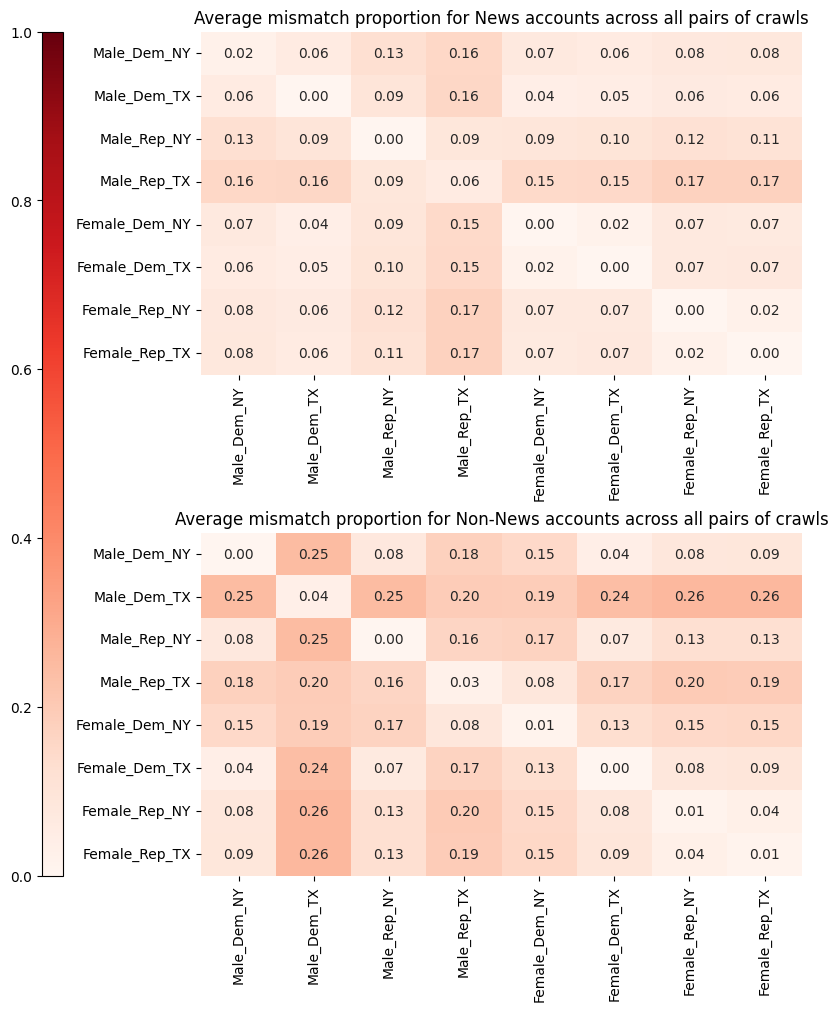

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(8, 10), constrained_layout=True)

hm0 = sns.heatmap(
    news_mismatch_no_rank_df, annot=True, fmt=".2f",
    cmap="Reds", vmin=0, vmax=1,
    ax=axes[0], cbar=False
)
axes[0].set_title(f"Average mismatch proportion for News accounts across all pairs of crawls")

hm1 = sns.heatmap(
    nonnews_mismatch_no_rank_df, annot=True, fmt=".2f",
    cmap="Reds", vmin=0, vmax=1,
    ax=axes[1], cbar=False
)
axes[1].set_title(f"Average mismatch proportion for Non-News accounts across all pairs of crawls")

cbar = fig.colorbar(
    hm0.collections[0],
    ax=axes,
    orientation="vertical",
    location="left", 
    pad=0.02,
    fraction=0.06,
    aspect=40
)
cbar.ax.xaxis.set_ticks_position("top")
cbar.ax.xaxis.set_label_position("top")

plt.savefig('/Users/brahmaninutakki/saarland/insta_comments/figures/heatmaps_no_rank.png',
            dpi=300,
            bbox_inches="tight",
            pad_inches=0.15)

/var/folders/sh/fhrqk28n1bzd27x7z4p52c940000gn/T/ipykernel_13796/1167862475.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap("Reds").copy()


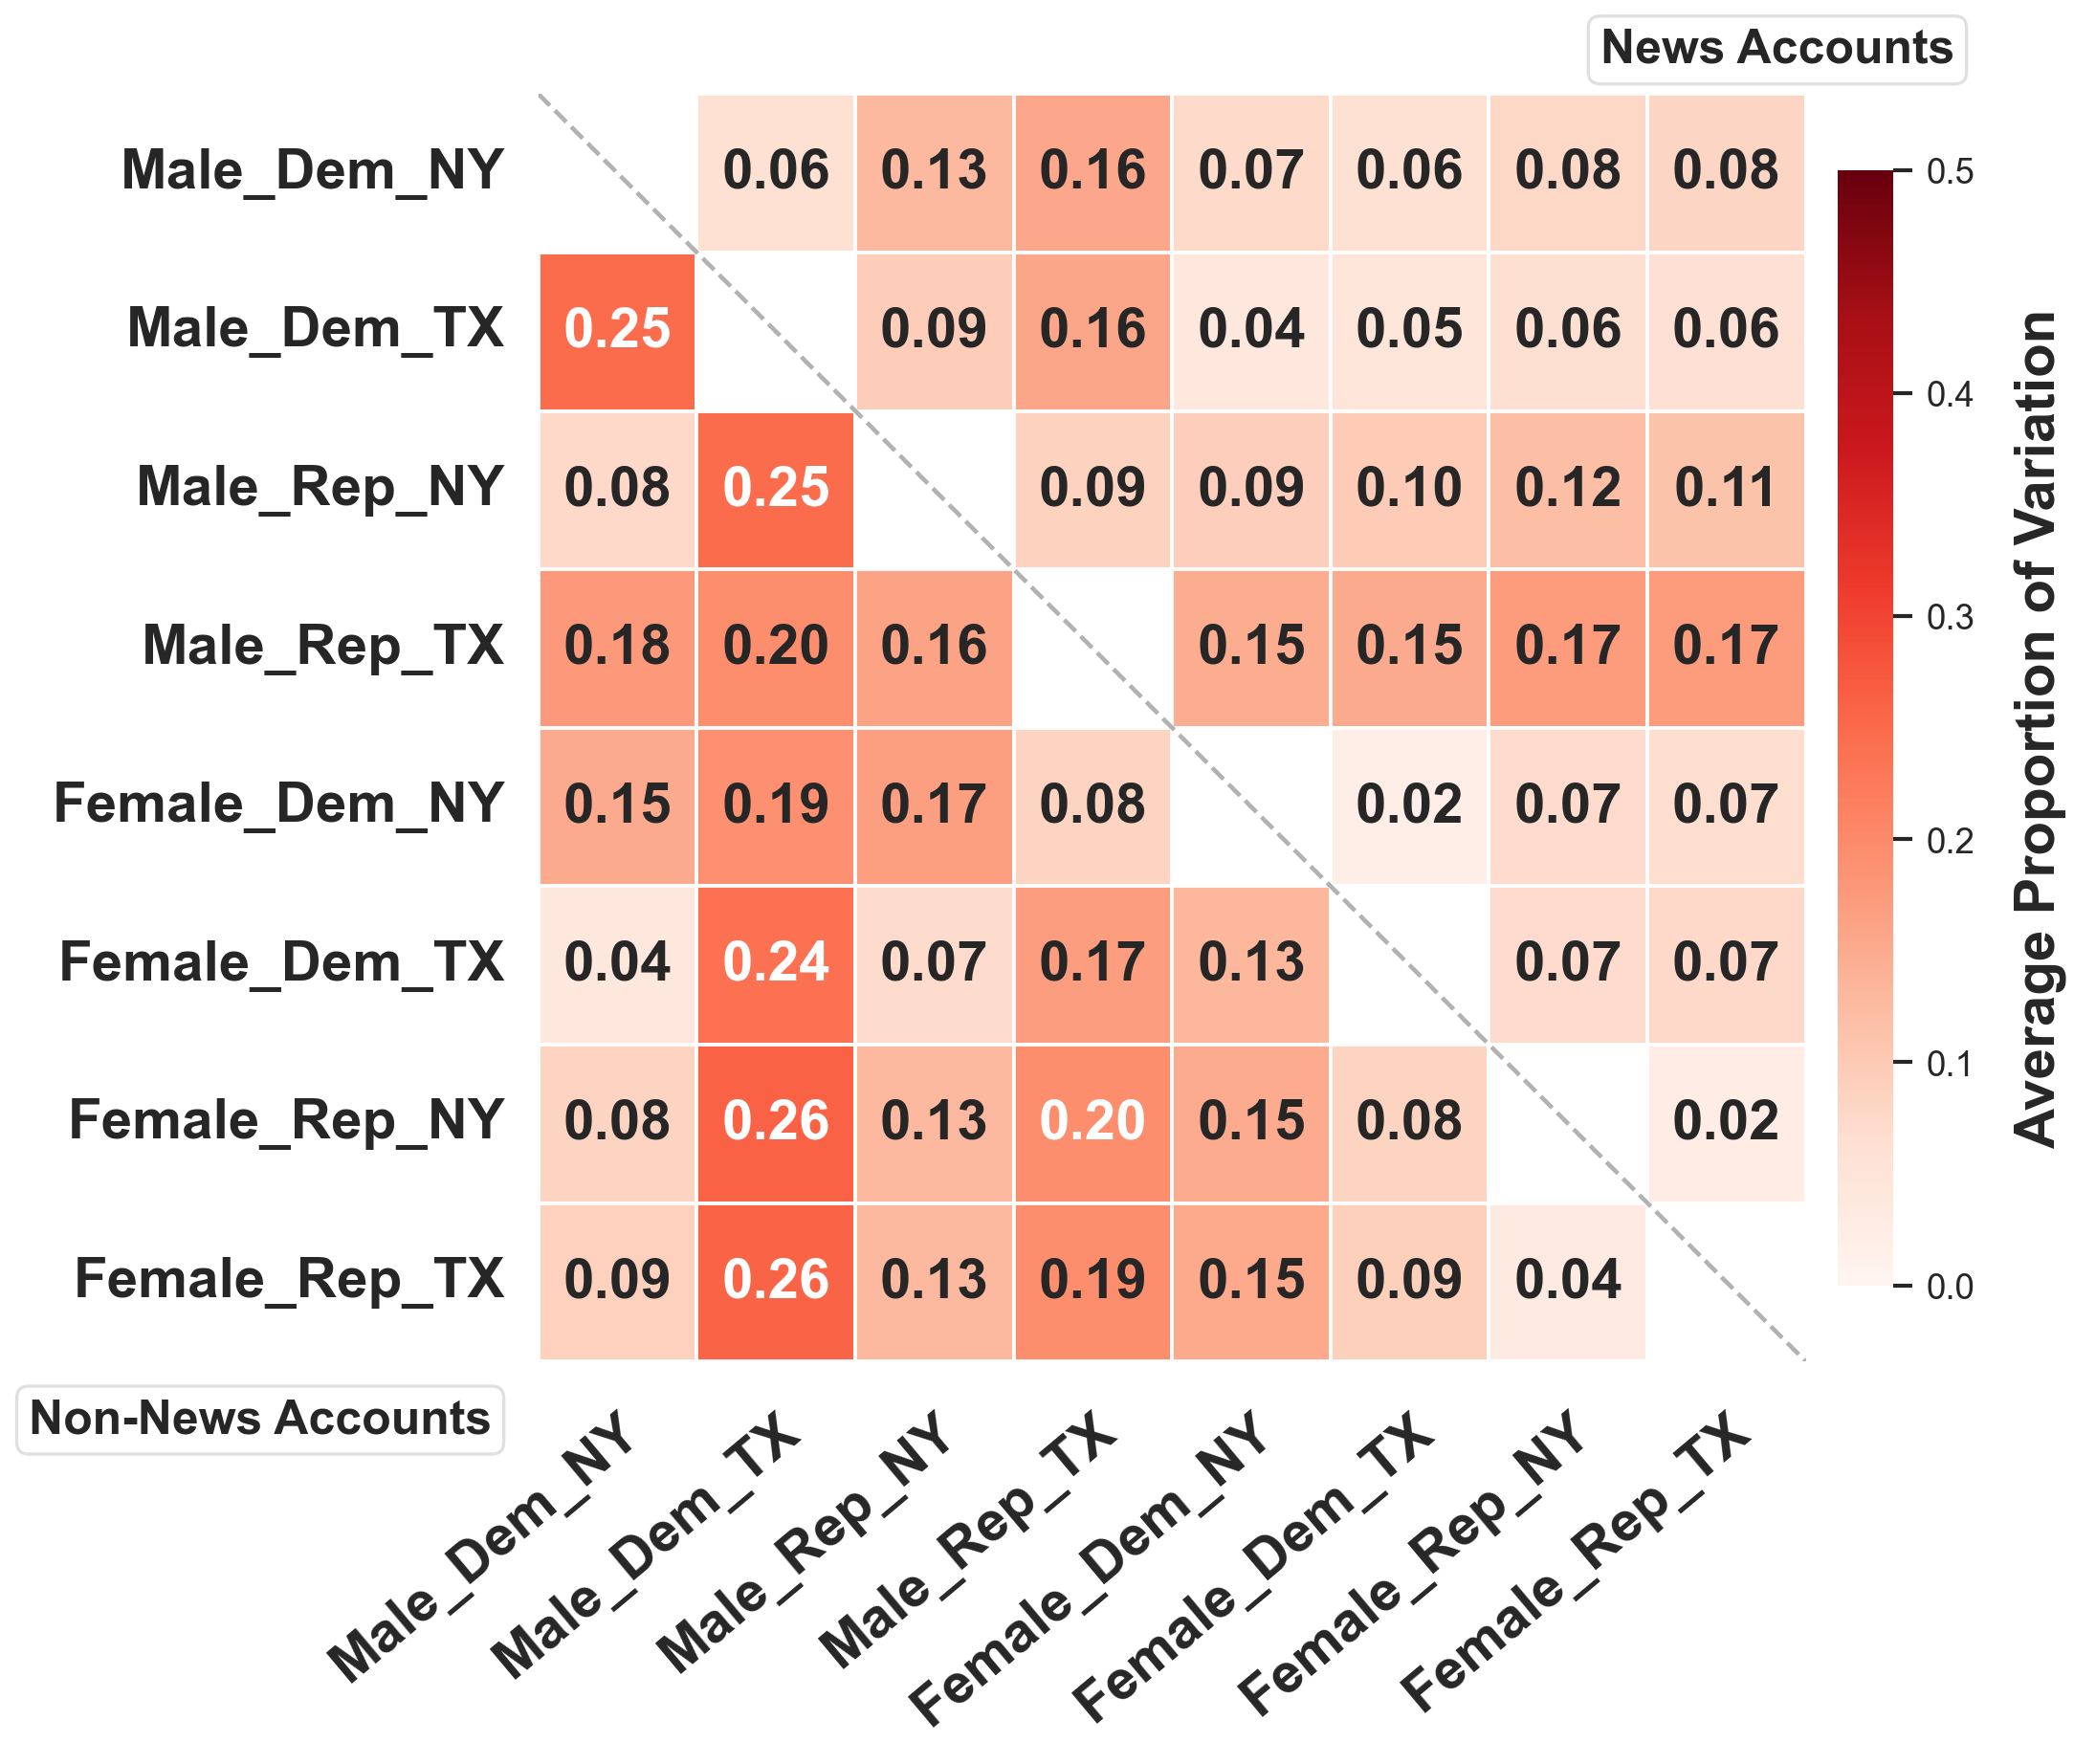

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

news, nonnews = news_mismatch_no_rank_df.align(nonnews_mismatch_no_rank_df)
n = news.shape[0]

combined = pd.DataFrame(np.nan, index=news.index, columns=news.columns)

upper = np.triu(np.ones((n, n), dtype=bool), k=1)
lower = np.tril(np.ones((n, n), dtype=bool), k=-1)

combined.values[upper] = news.values[upper]
combined.values[lower] = nonnews.values[lower]
np.fill_diagonal(combined.values, np.nan)

sns.set_theme(style="white", context="paper", font_scale=1.0)

cmap = mpl.cm.get_cmap("Reds").copy()
cmap.set_bad((1, 1, 1, 0))

fig, ax = plt.subplots(figsize=(7.4, 6.4), dpi=300)
ax.set_facecolor("white")

hm = sns.heatmap(
    combined,
    mask=combined.isna(),
    cmap=cmap, vmin=0, vmax=0.5,
    square=True,
    linewidths=0.5, linecolor=(1, 1, 1, 0.95),
    annot=True, fmt=".2f",
    annot_kws={"fontsize": 14, "fontweight": "bold"},
    cbar_kws={"shrink": 0.88, "pad": 0.02},
    ax=ax
)

# ticks
ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha="right", rotation_mode="anchor")
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
ax.tick_params(axis="x", labelsize=14, pad=6)
ax.tick_params(axis="y", labelsize=14)
for label in ax.get_xticklabels():
    label.set_fontweight('bold')

# Set font size and bold for y-axis tick labels
ax.tick_params(axis="y", labelsize=14)
for label in ax.get_yticklabels():
    label.set_fontweight('bold')
# diagonal separator (lighter + dashed)
ax.plot([0, n], [0, n], color=(0, 0, 0, 0.30), lw=1.1, ls="--")
# ax.set_ylim(0, 0.5) 

# colorbar label
cbar = hm.collections[0].colorbar
cbar.ax.set_ylabel("Average Proportion of Variation", rotation=90, labelpad=10,
                   fontsize=14, fontweight='bold')

# remove frame
for spine in ax.spines.values():
    spine.set_visible(False)

# ---- IMPORTANT: create extra room at bottom, then place labels in the margin ----
fig.subplots_adjust(bottom=0.26, top=0.95, left=0.22, right=0.97)

label_box = dict(
    facecolor=(1, 1, 1, 0.92),
    edgecolor=(0, 0, 0, 0.12),
    boxstyle="round,pad=0.25"
)

# place labels relative to the axes' position in the FIGURE (avoids tick-label collisions)
# pos = ax.get_position()

# fig.subplots_adjust(bottom=0.26, left=0.24, top=0.95, right=0.97)

pos = ax.get_position()

# Non-News label in the bottom-left corner BETWEEN x and y tick-label areas
fig.text(
    pos.x0 - 0.24,      # push left into the y-label margin
    pos.y0 - 0.02,      # slightly below the heatmap, but above the x tick-label block
    "Non-News Accounts",
    ha="left", va="top",
    fontsize=12, bbox=label_box,
    fontweight='bold'
)

fig.text(
    pos.x0 + 0.5, pos.y1 + 0.012,
    "News Accounts",
    ha="left", va="bottom",
    fontsize=12, bbox=label_box,
    fontweight='bold'
)

# fig.text(
#     pos.x0, pos.y0 - 0.085,   # safely below x tick labels because of bottom=0.26 above
#     "Non-News Accounts",
#     ha="left", va="top",
#     fontsize=10, bbox=label_box
# )

# plt.show()
plt.savefig('/Users/brahmaninutakki/saarland/insta_comments/figures/heatmaps_no_rank.png',
            dpi=300,
            bbox_inches="tight",
            pad_inches=0.15)


### post level reg 

In [15]:
reg_news_df = get_df_for_regression(news_df, news_urls, all_crawls)
reg_nonnews_df = get_df_for_regression(nonnews_df, nonnews_urls, all_crawls) 

In [16]:
reg_news_df.shape, reg_nonnews_df.shape

((4648, 9), (4312, 9))

In [17]:
reg_news_df.drop_duplicates(inplace=True)
reg_nonnews_df.drop_duplicates(inplace=True)

reg_news_df.shape, reg_nonnews_df.shape

((2114, 9), (2087, 9))

In [18]:
reg_news_df.dropna(inplace=True)
reg_nonnews_df.dropna(inplace=True)

reg_news_df.shape, reg_nonnews_df.shape

((2114, 9), (2087, 9))

In [19]:
display(reg_news_df[reg_news_df['fcount_no_rank'] == -1].shape), display(reg_nonnews_df[reg_nonnews_df['fcount_no_rank'] == -1].shape)
reg_news_df = reg_news_df[reg_news_df['fcount_no_rank'] != -1]
reg_nonnews_df = reg_nonnews_df[reg_nonnews_df['fcount_no_rank'] != -1]

reg_news_df.shape, reg_nonnews_df.shape

(45, 9)

(39, 9)

((2069, 9), (2048, 9))

In [20]:
accounts_data = pd.read_excel('/Users/brahmaninutakki/saarland/insta_comments/saved_data/News Sites US.xlsx', sheet_name='Reduced_NonPolitical_Accounts')
accounts_data.head(3)

reg_nonnews_df = pd.merge(reg_nonnews_df, accounts_data, on='account', how='inner')
reg_nonnews_df.shape

(2048, 12)

In [21]:
accounts_data = pd.read_excel('/Users/brahmaninutakki/saarland/insta_comments/saved_data/News Sites US.xlsx', sheet_name='Reduced_Political_Accounts')
accounts_data.head(3)

reg_news_df = pd.merge(reg_news_df, accounts_data, on='account', how='inner')
reg_news_df.shape

(2069, 15)

In [22]:
with open('/Users/brahmaninutakki/saarland/insta_comments/saved_data/comments_data_nonnews.json', 'r') as fp:
    metrics_data = json.load(fp)

likes_data = {}
comments_data = {}

for k, v in metrics_data.items():
    if len(v) == 2:
        likes_data[k] = numify_metrics(v[0])
        comments_data[k] = numify_metrics(v[1])
    elif len(v) == 1:
        likes_data[k] = numify_metrics(v[0])
        comments_data[k] = 0
    else:
        raise('Length error')

comments_df = pd.DataFrame(comments_data.items(), columns=['urlid', 'comments_count'])
likes_df = pd.DataFrame(likes_data.items(), columns=['urlid', 'likes_count'])

reg_nonnews_df = reg_nonnews_df.merge(comments_df, on='urlid', how='left')
reg_nonnews_df = reg_nonnews_df.merge(likes_df, on='urlid', how='left')

reg_nonnews_df[reg_nonnews_df['comments_count'].isna()]['urlid'].unique()

array(['DSC60BKkrYV'], dtype=object)

In [23]:
with open('/Users/brahmaninutakki/saarland/insta_comments/saved_data/comments_data_news.json', 'r') as fp:
    metrics_data = json.load(fp)

likes_data = {}
comments_data = {}

for k, v in metrics_data.items():
    if len(v) == 2:
        likes_data[k] = numify_metrics(v[0])
        comments_data[k] = numify_metrics(v[1])
    elif len(v) == 1:
        likes_data[k] = numify_metrics(v[0])
        comments_data[k] = 0
    else:
        raise('Length error')

comments_df = pd.DataFrame(comments_data.items(), columns=['urlid', 'comments_count'])
likes_df = pd.DataFrame(likes_data.items(), columns=['urlid', 'likes_count'])

reg_news_df = reg_news_df.merge(comments_df, on='urlid', how='left')
reg_news_df = reg_news_df.merge(likes_df, on='urlid', how='left')

reg_news_df[reg_news_df['comments_count'].isna()]['urlid'].unique()

array(['DRWBiQXDG0H', 'DRXIibxjFKK', 'DRW1V1nE_nd', 'DRXBM5Ojq4P',
       'DRYExbVkauI', 'DRYOJ1tkVa-', 'DRYXH9GlIcS', 'DRYaF2vj-hm',
       'DRYeCC9DP9C', 'DRYg5_ZlC-O', 'DRShUjTAcwn', 'DRVXN3TAbH-',
       'DRV4jnhkf2v', 'DRWCrncjAPT', 'DRWNKQPjO_h', 'DRX7mPtkhbo',
       'DRXVJ4LkQVH', 'DRXeikNDutF', 'DRXyanzDw2z', 'DRK7-xAEaGg',
       'DRNAF39ESYr', 'DRNI1TVEZ90', 'DRNOKZMkZv9', 'DRVZKhOkeKw',
       'DRV4-1ck1EG', 'DRXO1Q9Co1Y', 'DRX71AeCgTh', 'DRYGzcyEsGL'],
      dtype=object)

In [24]:
accounts_data = pd.read_excel('/Users/brahmaninutakki/saarland/insta_comments/saved_data/News Sites US.xlsx', sheet_name='Missing Comments')
accounts_data.head(3)

reg_news_df = pd.merge(reg_news_df, accounts_data, on='urlid', how='outer')

reg_news_df[['comments_count', 'comments_mising']].describe()

,comments_count,comments_mising
count,1392.000000,677.000000
mean,849.701149,1681.441654
std,2137.699421,2728.958771
min,14.000000,17.000000
25%,89.000000,119.000000
50%,260.000000,564.000000
75%,846.000000,1839.000000
max,15100.000000,13602.000000


In [25]:
reg_news_df['comments_count'] = reg_news_df["comments_count"].fillna(reg_news_df["comments_mising"])
reg_news_df[['comments_count', 'comments_mising']].describe()
reg_news_df.drop(columns=['comments_mising'], inplace=True)

In [26]:
reg_nonnews_df = reg_nonnews_df[reg_nonnews_df['urlid'] != 'DSC60BKkrYV']

In [27]:
posts_data = pd.read_excel('/Users/brahmaninutakki/saarland/insta_comments/saved_data/News Sites US.xlsx', sheet_name='New data topics')
posts_data['urlid'] = posts_data['Url'].apply(lambda x: x.split('/')[-2] if x.endswith('/') else x.split('/')[-1])
posts_data = posts_data[posts_data['urlid'].isin(reg_news_df['urlid'].unique().tolist())]
posts_data.shape[0] == reg_news_df['urlid'].nunique()

reg_news_df = pd.merge(reg_news_df, posts_data, on='urlid', how='inner')
reg_news_df.drop(columns=['Url'], inplace=True)
reg_news_df.shape

(2069, 21)

In [28]:
reg_news_df['type'] = 'News'
reg_nonnews_df['main_topic'] = 'Non-Political'
reg_nonnews_df['type'] = 'Non-News'

In [29]:
concat_df = pd.concat([reg_nonnews_df, reg_news_df], ignore_index=True)
concat_df.shape

(4114, 22)

In [30]:
def preprocess_reg(df):
    df['fcount_no_rank'] = df['fcount_no_rank'].astype(int)
    df['ftrials_no_rank'] = df['ftrials_no_rank'].astype(int)
    df['fcount_rank'] = df['fcount_rank'].astype(int)
    df['ftrials_rank'] = df['ftrials_rank'].astype(int)

    (df[df['fcount_no_rank'] > df['ftrials_no_rank']]).shape, (df[df['fcount_rank'] > df['ftrials_rank']]).shape

    df['gender_diff'] = df['gender'].apply(lambda x: 'No' if x in ['female_female', 'male_male'] else 'Yes')
    df['location_diff'] = df['location'].apply(lambda x: 'No' if x in ['ny_ny', 'texas_texas'] else 'Yes')
    df['ideology_diff'] = df['ideology'].apply(lambda x: 'No' if x in ['dem_dem', 'rep_rep'] else 'Yes')

    for col in ["posts", "followers", "following", "comments_count"]:
        new = col + "_logz"
        x = np.log1p(df[col].astype(float))
        df[new] = (x - x.mean()) / x.std(ddof=0)


    df["gender"] = pd.Categorical(
        df["gender"],
        categories=["male_male", "female_male", "female_female"],
        ordered=True
    )

    df["ideology"] = pd.Categorical(
        df["ideology"],
        categories=["rep_rep", "dem_rep", "dem_dem"],
        ordered=True
    )

    df["location"] = pd.Categorical(
        df["location"],
        categories=["texas_texas", "ny_texas", "ny_ny"],
        ordered=True
    )

    df['type'] = pd.Categorical(
        df['type'],
        categories=['Non-News', 'News'],
        ordered=True
    )


    df['main_topic'] = pd.Categorical(
        df['main_topic'],
        categories=['Political', 'Non-Political'],
        ordered=True
    )

    df["gender_diff"] = pd.Categorical(
        df["gender_diff"],
        categories=["No", "Yes"],
        ordered=True
    )

    df["ideology_diff"] = pd.Categorical(
        df["ideology_diff"],
        categories=["No", "Yes"],
        ordered=True
    )

    df["location_diff"] = pd.Categorical(
        df["location_diff"],
        categories=["No", "Yes"],
        ordered=True
    )

    return df

In [31]:
concat_df = preprocess_reg(concat_df)
reg_news_df = preprocess_reg(reg_news_df)
reg_nonnews_df = preprocess_reg(reg_nonnews_df)

In [32]:
news_df['account'].value_counts()

account
cnn               130
foxnews           119
nypost            112
huffpost          110
breitbart         108
msnbc             105
thehill           105
forbes             99
washingtonpost     92
Name: count, dtype: int64

In [33]:
formula = "fcount_no_rank ~ gender_diff + location_diff + ideology_diff + C(type) + C(main_topic) + followers_logz + comments_count_logz + followers_logz + following_logz + posts_logz " 
get_vif(formula, concat_df)

,feature,VIF
8,following_logz,1.040989
1,gender_diff[T.Yes],1.081578
3,ideology_diff[T.Yes],1.083115
2,location_diff[T.Yes],1.091950
9,posts_logz,1.159960
6,followers_logz,1.276795
7,comments_count_logz,1.365146
4,C(type)[T.News],1.506742
5,C(main_topic)[T.Non-Political],1.771937
0,Intercept,16.689596


#### combined

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (4 chains in 1 job)
NUTS: [kappa, Intercept, location, gender, ideology, followers_logz, comments_count_logz, type, 1|urlid_sigma, 1|urlid_offset]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 690 seconds.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Intercept,-1.613,0.139,-1.875,-1.354,0.005,0.002,862.0,1820.0,1.01
Location[ny_texas],-0.320,0.041,-0.397,-0.242,0.000,0.000,7825.0,5855.0,1.00
Location[ny_ny],-0.268,0.048,-0.359,-0.178,0.001,0.001,8131.0,6225.0,1.00
Gender[female_male],-0.108,0.042,-0.184,-0.028,0.000,0.000,8229.0,5863.0,1.00
Gender[female_female],-0.553,0.054,-0.653,-0.452,0.001,0.001,8709.0,5593.0,1.00
Leaning[dem_rep],0.019,0.042,-0.056,0.099,0.000,0.000,8248.0,6109.0,1.00
Leaning[dem_dem],-0.171,0.051,-0.269,-0.079,0.001,0.001,9252.0,6262.0,1.00
Comments (log z),0.651,0.100,0.463,0.838,0.003,0.002,1016.0,1399.0,1.00
Account Type[News],-1.195,0.186,-1.534,-0.835,0.006,0.003,894.0,1717.0,1.01
Followers (log z),-0.268,0.098,-0.454,-0.087,0.004,0.002,647.0,1315.0,1.00


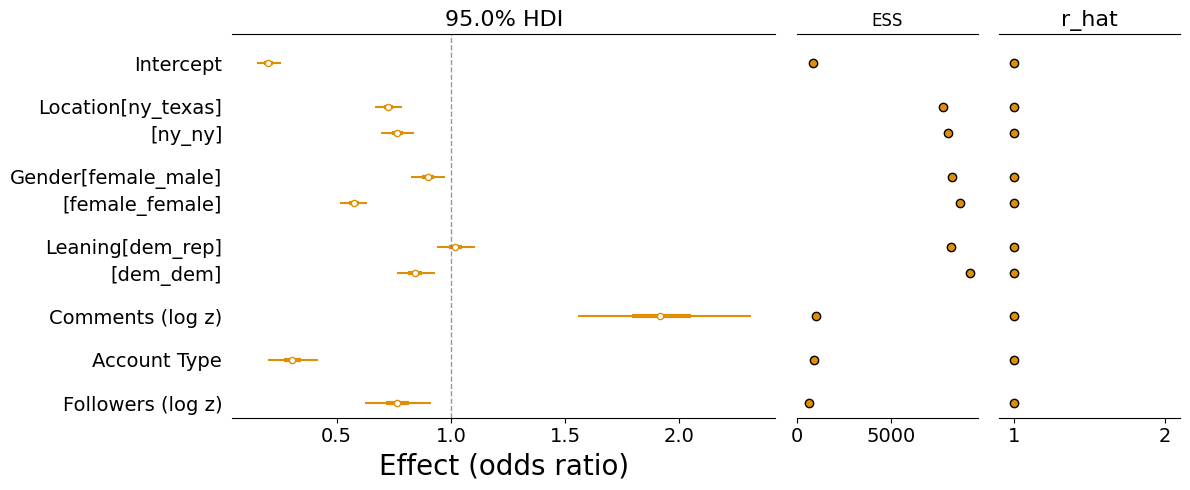

In [35]:
model = bmb.Model(
    "p(fcount_no_rank, ftrials_no_rank) ~ location + gender + ideology + followers_logz + comments_count_logz + type + (1|urlid)",
    data=concat_df,
    family="beta_binomial",
    # dropna=True
)

results = model.fit(
    draws=2000,      
    tune=2000,       
    target_accept=0.97,
    chains=4,
    cores=1,
    random_seed=42,
    prob=0.95
)

var_names = ['Intercept', 'location', 'gender', 'ideology',
             'comments_count_logz', 'type', 'followers_logz']

df = az.summary(results, var_names=var_names)
df = df.rename(index=edit_labels)
display(df)

axes = az.plot_forest(
    results,
    hdi_prob=0.95,
    transform=np.exp,
    figsize=(12, 5),
    r_hat=True,
    ess=True,
    var_names=var_names,
    colors='C1',
    combined=True,
)
TITLE_FS = 22
LABEL_FS = 20
TICK_FS  = 20
LEG_FS   = 20
ax = axes[0] if isinstance(axes, (list, np.ndarray)) else axes
axes[1].set_title("ESS")
new_labels = [edit_labels(t.get_text()) for t in ax.get_yticklabels()]
ax.set_yticklabels(new_labels)

ax.axvline(1, linestyle="--", linewidth=1, color="grey", alpha=0.8)
ax.set_xlabel("Effect (odds ratio)", fontsize=LABEL_FS)
plt.tight_layout()
# plt.show()
plt.savefig('/Users/brahmaninutakki/saarland/insta_comments/figures/forestplot_combined.png', dpi=300)

Default computed for unspecified variable: comments_count_logz, followers_logz, gender, ideology, type, urlid
Default computed for unspecified variable: comments_count_logz, followers_logz, ideology, location, type, urlid
Default computed for unspecified variable: comments_count_logz, followers_logz, gender, location, type, urlid
Default computed for unspecified variable: comments_count_logz, followers_logz, gender, ideology, location, urlid
Default computed for conditional variable: followers_logz
Default computed for unspecified variable: comments_count_logz, gender, ideology, location, type, urlid
Default computed for conditional variable: comments_count_logz
Default computed for unspecified variable: followers_logz, gender, ideology, location, type, urlid


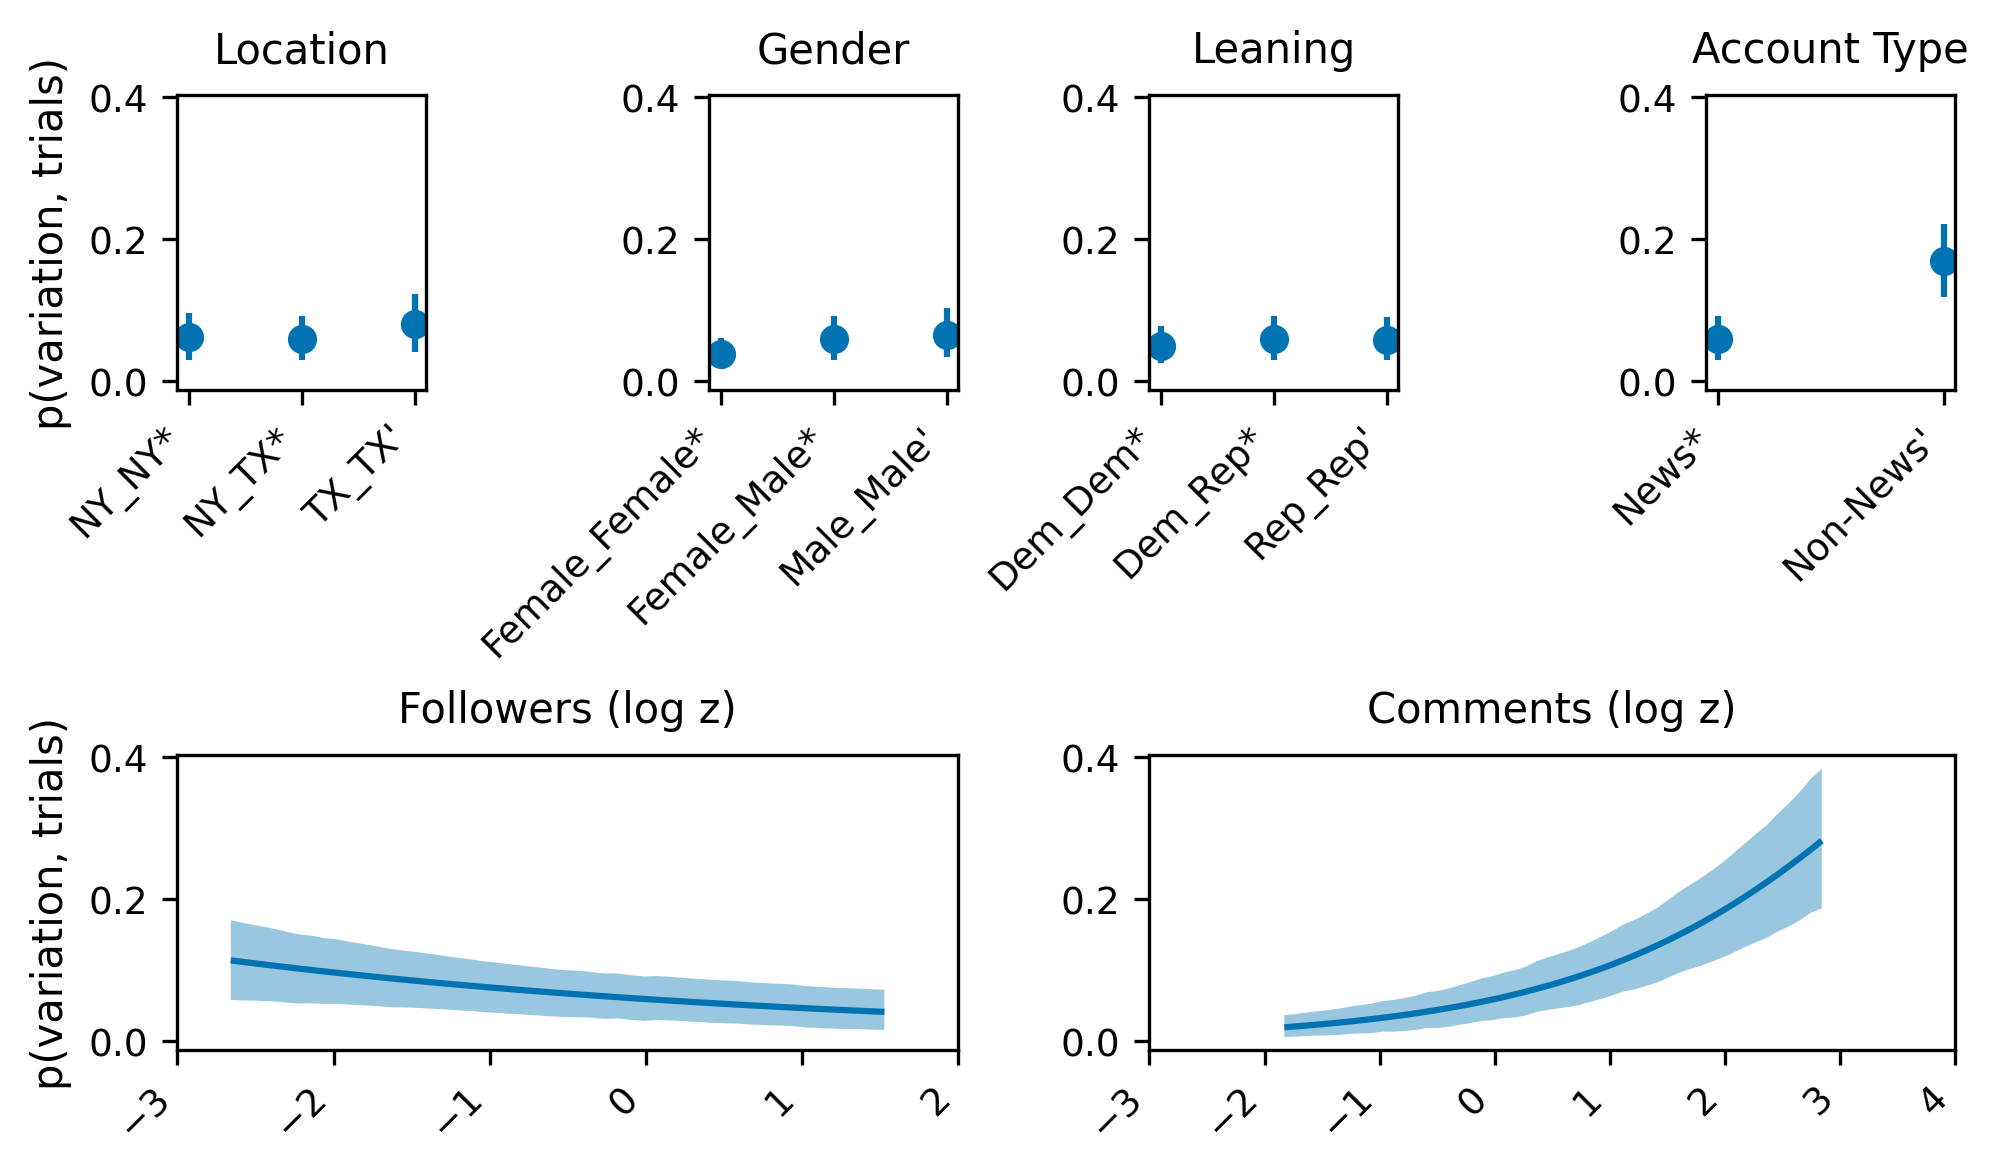

In [52]:
first_row = ["location", "gender", "ideology", "type"]
second_row = ["followers_logz", "comments_count_logz", 'main_topic']
conditionals = first_row + second_row

TITLE_FS = 10
LABEL_FS = 10
TICK_FS  = 9
LEG_FS   = 9

data = model.data 

fig = plt.figure(figsize=(6.5, 3.8), dpi=300, constrained_layout=True)
gs = fig.add_gridspec(2, 4)

axes = []
ax0 = fig.add_subplot(gs[0, 0])
axes.append(ax0)

for c in range(1, 4):
    axes.append(fig.add_subplot(gs[0, c], sharey=ax0))

axes.append(fig.add_subplot(gs[1, 0:2], sharey=ax0))
axes.append(fig.add_subplot(gs[1, 2:4], sharey=ax0))

def conditional_spec(var):
    u = pd.Series(data[var]).dropna().unique().tolist()
    if len(u) <= 5:
        try:
            u_sorted = sorted(u, key=lambda x: float(x))
        except Exception:
            u_sorted = sorted(u, key=lambda x: str(x))
        return {var: u_sorted}, u_sorted
    return var, None

for ax, var in zip(axes, conditionals):
    cond, levels = conditional_spec(var)

    fig2, _ = bmb.interpret.plot_predictions(
        model, results,
        conditional=cond,
        prob=0.95,
        use_hdi=True,
        pps=False,
        legend=False,
        ax=ax,
    )
    if fig2 is not fig:
        plt.close(fig2)

    for line in ax.lines:
        line.set_markersize(2)


    ax.set_title(edit_labels(var))
    ax.set_xlabel('')

    leg = ax.get_legend()
    if leg is not None:
        for t in leg.get_texts():
            t.set_text(edit_labels(t.get_text()))
        leg.set_title(edit_labels(leg.get_title().get_text()))


    # Title
    ax.set_title(edit_labels(var), fontsize=TITLE_FS, pad=8)

    # Axis labels (keep x blank if you want, but set sizes anyway)
    ax.set_xlabel(ax.get_xlabel(), fontsize=LABEL_FS)
    ax.set_ylabel(ax.get_ylabel(), fontsize=LABEL_FS)

    # Tick label sizes
    ax.tick_params(axis="both", which="major", labelsize=TICK_FS, labelrotation=0)

    # inside your loop, after plot_predictions(...)
    ticks = ax.get_xticks()
    ticklabels = [util.edit_labels(t.get_text()) for t in ax.get_xticklabels()]

    # apply your label editing function
    ax.set_xticks(ticks)
    ax.set_xticklabels([util.edit_labels(s) for s in ticklabels],
                    fontsize=TICK_FS, rotation=45, ha="right")

    # Legend text size (if any legend appears)
    leg = ax.get_legend()
    if leg is not None:
        leg.set_title(edit_labels(leg.get_title().get_text()))
        leg.get_title().set_fontsize(LEG_FS)
        for t in leg.get_texts():
            t.set_text(edit_labels(t.get_text()))
            t.set_fontsize(LEG_FS)

    if ax is ax0 or ax is axes[4]:
        ax.set_ylabel('p(variation, trials)', fontsize=LABEL_FS)
    else:
        ax.set_ylabel('')


    if isinstance(cond, dict) and levels is not None:
        try:
            lv = np.array(levels, dtype=float)
            if lv.size == 2:
                ax.set_xlim(lv.min() - 0.2, lv.max() + 0.2)
                ax.set_xticks(sorted(lv))
        except Exception:
            pass


axes[3].set_title("Account Type", fontsize=TITLE_FS, pad=8)

plt.rcParams.update({
    "font.size": 10,
    "axes.titlesize": TITLE_FS,
    "axes.labelsize": LABEL_FS,
    "xtick.labelsize": TICK_FS,
    "ytick.labelsize": TICK_FS,
    "legend.fontsize": LEG_FS,
})

plt.savefig('/Users/brahmaninutakki/saarland/insta_comments/figures/ppp_combined.png', dpi=300, bbox_inches='tight')

In [36]:
# model = bmb.Model(
#     "p(fcount_no_rank, ftrials_no_rank) ~ location + gender + ideology + main_topic + (1|account) + (1|urlid)",
#     data=reg_news_df,
#     family="beta_binomial",
#     # dropna=True
# )

# results = model.fit(
#     draws=2000,      
#     tune=2000,       
#     target_accept=0.99,
#     chains=4,
#     cores=1,
#     random_seed=24,
#     prob=0.95
# )

# var_names = ['Intercept', 'location', 'gender', 'ideology',
#              'main_topic']

# df = az.summary(results, var_names=var_names)
# df = df.rename(index=edit_labels)
# display(df)

# axes = az.plot_forest(
#     results,
#     hdi_prob=0.95,
#     transform=np.exp,
#     figsize=(12, 5),
#     r_hat=True,
#     ess=True,
#     var_names=var_names,
#     colors='C1',
#     combined=True,
# )

# ax = axes[0] if isinstance(axes, (list, np.ndarray)) else axes
# axes[1].set_title("ESS")
# new_labels = [edit_labels(t.get_text()) for t in ax.get_yticklabels()]
# ax.set_yticklabels(new_labels)

# ax.axvline(1, linestyle="--", linewidth=1, color="grey", alpha=0.8)
# ax.set_xlabel("Effect (odds ratio)")
# plt.tight_layout()
# # plt.show()
# plt.savefig('/Users/brahmaninutakki/saarland/insta-comments/figures/forestplot_main_topic_news.png', dpi=300)

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (4 chains in 1 job)
NUTS: [kappa, Intercept, location, gender, ideology, main_topic, 1|account_sigma, 1|account_offset, 1|urlid_sigma, 1|urlid_offset]


Output()

Default computed for unspecified variable: account, gender, ideology, main_topic, urlid
Default computed for unspecified variable: account, ideology, location, main_topic, urlid
Default computed for unspecified variable: account, gender, location, main_topic, urlid
Default computed for unspecified variable: account, gender, ideology, location, urlid


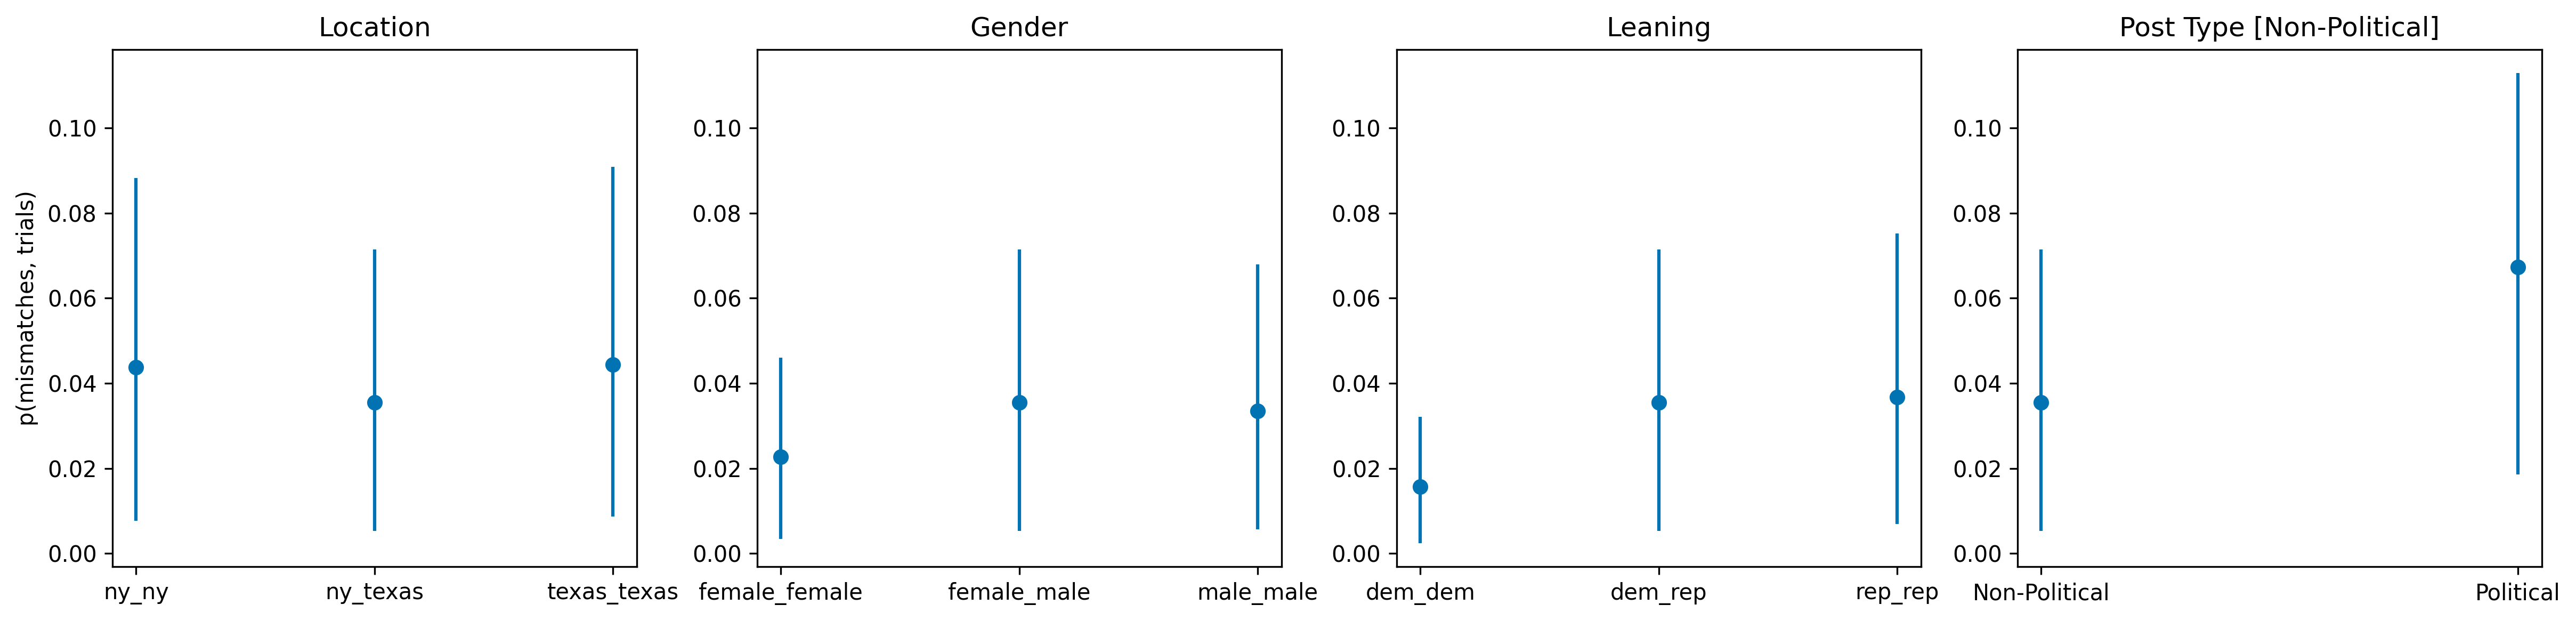

In [ ]:
# first_row = ["location", "gender", "ideology", "main_topic"]
# second_row = []
# conditionals = first_row + second_row

# data = model.data 

# fig = plt.figure(figsize=(16, 7), dpi=300, constrained_layout=True)
# gs = fig.add_gridspec(2, 4)

# axes = []
# ax0 = fig.add_subplot(gs[0, 0])
# axes.append(ax0)

# for c in range(1, 4):
#     axes.append(fig.add_subplot(gs[0, c], sharey=ax0))

# axes.append(fig.add_subplot(gs[1, 0:2], sharey=ax0))
# axes.append(fig.add_subplot(gs[1, 2:4], sharey=ax0))

# def conditional_spec(var):
#     u = pd.Series(data[var]).dropna().unique().tolist()
#     if len(u) <= 5:
#         try:
#             u_sorted = sorted(u, key=lambda x: float(x))
#         except Exception:
#             u_sorted = sorted(u, key=lambda x: str(x))
#         return {var: u_sorted}, u_sorted
#     return var, None

# for ax, var in zip(axes, conditionals):
#     cond, levels = conditional_spec(var)

#     fig2, _ = bmb.interpret.plot_predictions(
#         model, results,
#         conditional=cond,
#         prob=0.95,
#         use_hdi=True,
#         pps=False,
#         legend=False,
#         ax=ax,
#     )
#     if fig2 is not fig:
#         plt.close(fig2)


#     ax.set_title(edit_labels(var))
#     ax.set_xlabel('')

#     leg = ax.get_legend()
#     if leg is not None:
#         for t in leg.get_texts():
#             t.set_text(edit_labels(t.get_text()))
#         leg.set_title(edit_labels(leg.get_title().get_text()))

#     if isinstance(cond, dict) and levels is not None:
#         try:
#             lv = np.array(levels, dtype=float)
#             if lv.size == 2:
#                 ax.set_xlim(lv.min() - 0.2, lv.max() + 0.2)
#                 ax.set_xticks(sorted(lv))
                
#         except Exception:
#             pass

# ax0.set_ylabel('p(mismatches, trials)')
# for ax in axes[1:]:
#     ax.set_ylabel("")

# for ax in axes[len(conditionals):]:
#     fig.delaxes(ax) 

# plt.savefig('/Users/brahmaninutakki/saarland/insta-comments/figures/ppp_maintopic_news.png', dpi=300)

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (4 chains in 1 job)
NUTS: [kappa, Intercept, location, gender, ideology, main_topic, political_ideology, comments_count_logz, followers_logz, 1|urlid_sigma, 1|urlid_offset]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 2027 seconds.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Intercept,-2.868,0.554,-3.893,-1.813,0.009,0.007,3590.0,4263.0,1.0
Location[ny_texas],-0.237,0.058,-0.341,-0.122,0.001,0.001,11277.0,6192.0,1.0
Location[ny_ny],-0.016,0.064,-0.132,0.109,0.001,0.001,11293.0,6618.0,1.0
Gender[female_male],0.060,0.059,-0.050,0.171,0.001,0.001,10689.0,6274.0,1.0
Gender[female_female],-0.402,0.076,-0.549,-0.261,0.001,0.001,11072.0,6331.0,1.0
Leaning[dem_rep],-0.037,0.056,-0.136,0.073,0.001,0.001,9426.0,6283.0,1.0
Leaning[dem_dem],-0.882,0.082,-1.037,-0.728,0.001,0.001,10729.0,5898.0,1.0
Post Type [Non-Political][Non-Political],-0.141,0.464,-1.016,0.732,0.008,0.006,3600.0,4403.0,1.0
political_ideology[Center-Left],0.414,0.730,-0.962,1.803,0.013,0.010,3256.0,3761.0,1.0
political_ideology[Center-Right],-0.336,0.658,-1.570,0.909,0.011,0.008,3562.0,4128.0,1.0


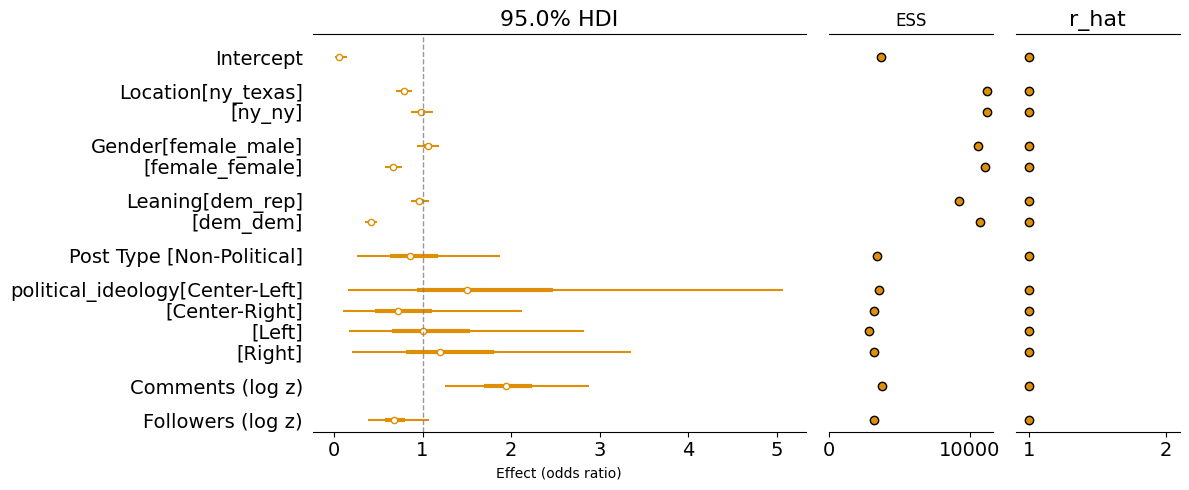

In [36]:
# model = bmb.Model(
#     "p(fcount_no_rank, ftrials_no_rank) ~ location + gender + ideology + main_topic + political_ideology + comments_count_logz + followers_logz + (1|urlid)",
#     data=reg_news_df,
#     family="beta_binomial",
#     # dropna=True
# )

# results = model.fit(
#     draws=2000,      
#     tune=2000,       
#     target_accept=0.99,
#     chains=4,
#     cores=1,
#     random_seed=24,
#     prob=0.95
# )

# var_names = ['Intercept', 'location', 'gender', 'ideology',
#              'main_topic', 'political_ideology', 'comments_count_logz', 'followers_logz']

# df = az.summary(results, var_names=var_names)
# df = df.rename(index=edit_labels)
# display(df)

# axes = az.plot_forest(
#     results,
#     hdi_prob=0.95,
#     transform=np.exp,
#     figsize=(12, 5),
#     r_hat=True,
#     ess=True,
#     var_names=var_names,
#     colors='C1',
#     combined=True,
# )

# ax = axes[0] if isinstance(axes, (list, np.ndarray)) else axes
# axes[1].set_title("ESS")
# new_labels = [edit_labels(t.get_text()) for t in ax.get_yticklabels()]
# ax.set_yticklabels(new_labels)

# ax.axvline(1, linestyle="--", linewidth=1, color="grey", alpha=0.8)
# ax.set_xlabel("Effect (odds ratio)")
# plt.tight_layout()
# plt.show()
# # plt.savefig('/Users/brahmaninutakki/saarland/insta-comments/figures/forestplot_main_topic_news.png', dpi=300)

Default computed for unspecified variable: comments_count_logz, followers_logz, gender, ideology, main_topic, political_ideology, urlid
Default computed for unspecified variable: comments_count_logz, followers_logz, ideology, location, main_topic, political_ideology, urlid
Default computed for unspecified variable: comments_count_logz, followers_logz, gender, location, main_topic, political_ideology, urlid
Default computed for unspecified variable: comments_count_logz, followers_logz, gender, ideology, location, political_ideology, urlid
Default computed for unspecified variable: comments_count_logz, followers_logz, gender, ideology, location, main_topic, urlid
Default computed for conditional variable: comments_count_logz
Default computed for unspecified variable: followers_logz, gender, ideology, location, main_topic, political_ideology, urlid


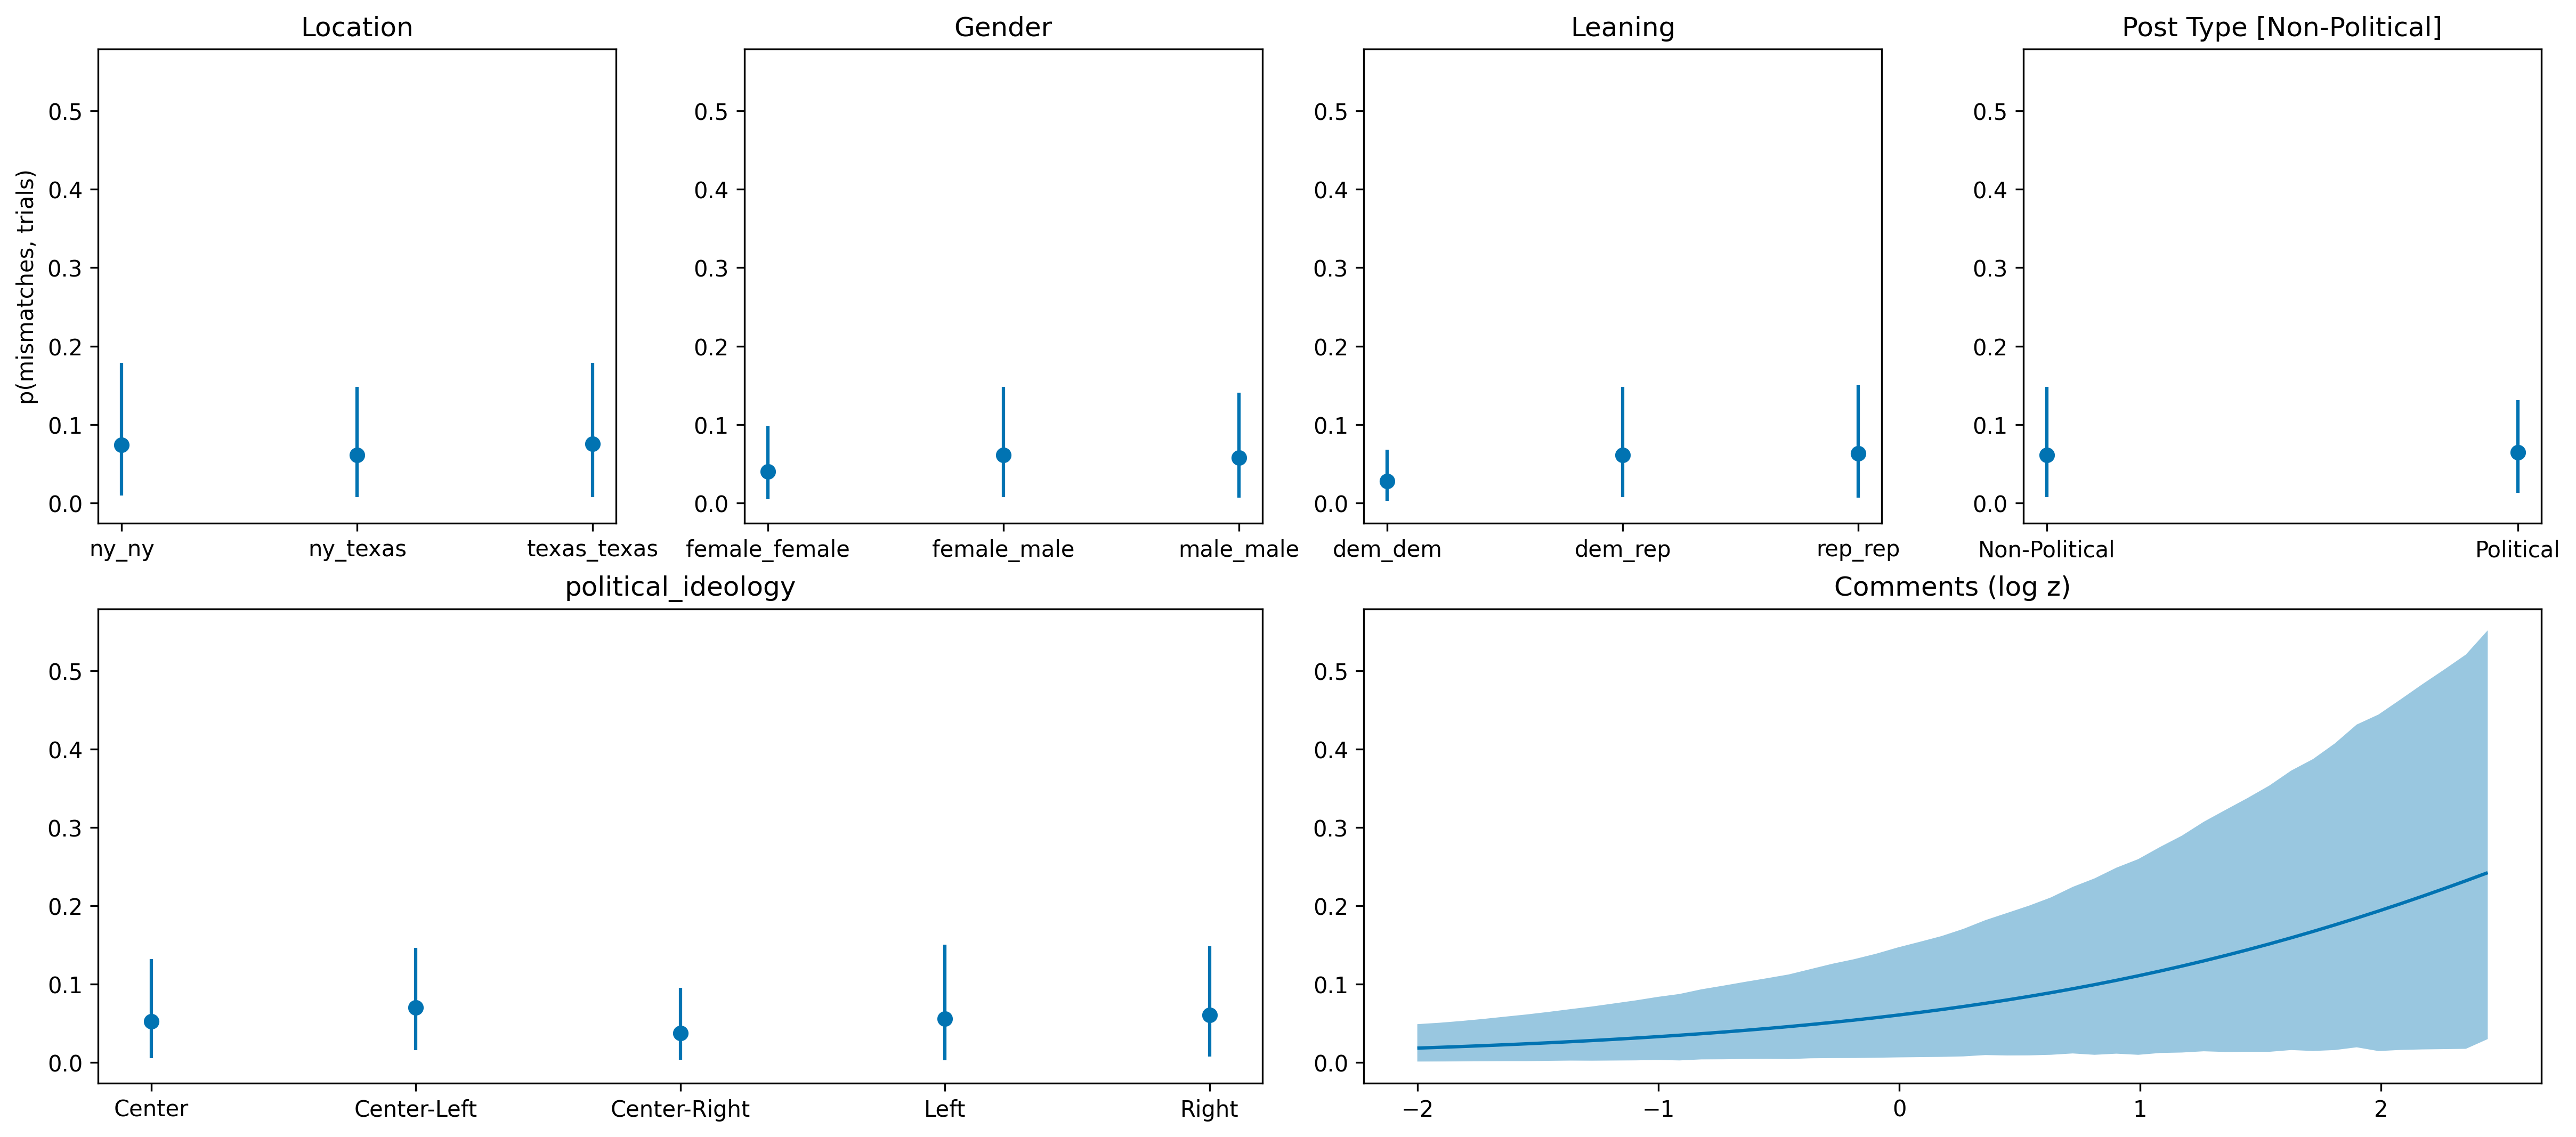

In [37]:
# first_row = ['location', 'gender', 'ideology',
#              'main_topic', 'political_ideology', 'comments_count_logz', 'followers_logz']
# second_row = []
# conditionals = first_row + second_row

# data = model.data 

# fig = plt.figure(figsize=(16, 7), dpi=300, constrained_layout=True)
# gs = fig.add_gridspec(2, 4)

# axes = []
# ax0 = fig.add_subplot(gs[0, 0])
# axes.append(ax0)

# for c in range(1, 4):
#     axes.append(fig.add_subplot(gs[0, c], sharey=ax0))

# axes.append(fig.add_subplot(gs[1, 0:2], sharey=ax0))
# axes.append(fig.add_subplot(gs[1, 2:4], sharey=ax0))

# def conditional_spec(var):
#     u = pd.Series(data[var]).dropna().unique().tolist()
#     if len(u) <= 5:
#         try:
#             u_sorted = sorted(u, key=lambda x: float(x))
#         except Exception:
#             u_sorted = sorted(u, key=lambda x: str(x))
#         return {var: u_sorted}, u_sorted
#     return var, None

# for ax, var in zip(axes, conditionals):
#     cond, levels = conditional_spec(var)

#     fig2, _ = bmb.interpret.plot_predictions(
#         model, results,
#         conditional=cond,
#         prob=0.95,
#         use_hdi=True,
#         pps=False,
#         legend=False,
#         ax=ax,
#     )
#     if fig2 is not fig:
#         plt.close(fig2)


#     ax.set_title(edit_labels(var))
#     ax.set_xlabel('')

#     leg = ax.get_legend()
#     if leg is not None:
#         for t in leg.get_texts():
#             t.set_text(edit_labels(t.get_text()))
#         leg.set_title(edit_labels(leg.get_title().get_text()))

#     if isinstance(cond, dict) and levels is not None:
#         try:
#             lv = np.array(levels, dtype=float)
#             if lv.size == 2:
#                 ax.set_xlim(lv.min() - 0.2, lv.max() + 0.2)
#                 ax.set_xticks(sorted(lv))
#         except Exception:
#             pass

# ax0.set_ylabel('p(mismatches, trials)')
# for ax in axes[1:]:
#     ax.set_ylabel("")

# for ax in axes[len(conditionals):]:
#     fig.delaxes(ax) 

# # plt.savefig('/Users/brahmaninutakki/saarland/insta-comments/figures/ppp_maintopic_news.png', dpi=300)
# plt.show()

### political/non-political

In [15]:
reg_news_df = get_df_for_regression(news_df, news_urls, all_crawls)

In [16]:
reg_news_df.shape

(4648, 9)

In [17]:
reg_news_df

,location,gender,ideology,urlid,account,fcount_no_rank,ftrials_no_rank,fcount_rank,ftrials_rank
0,ny_texas,male_male,dem_dem,DRWBiQXDG0H,breitbart,0.0,20.0,3.0,10.0
1,ny_texas,male_male,dem_dem,DRWXFT9DRtK,breitbart,0.0,20.0,4.0,10.0
2,ny_texas,male_male,dem_dem,DRWhnmjDo-i,breitbart,0.0,20.0,2.0,10.0
3,ny_texas,male_male,dem_dem,DRXIibxjFKK,breitbart,2.0,20.0,5.0,9.0
4,ny_texas,male_male,dem_dem,DRXUNHfDYvW,breitbart,0.0,20.0,0.0,10.0
...,...,...,...,...,...,...,...,...,...
4643,ny_texas,female_female,rep_rep,DRX-31ODa_2,washingtonpost,0.0,20.0,4.0,10.0
4644,ny_texas,female_female,rep_rep,DRXO1Q9Co1Y,washingtonpost,0.0,20.0,0.0,10.0
4645,ny_texas,female_female,rep_rep,DRXf-IGj2TH,washingtonpost,0.0,20.0,2.0,10.0
4646,ny_texas,female_female,rep_rep,DRXw_eDjr9l,washingtonpost,0.0,20.0,0.0,10.0


In [18]:
reg_news_df.drop_duplicates(inplace=True)
reg_news_df.dropna(inplace=True)

reg_news_df.shape

(2114, 9)

In [34]:
accounts_data = pd.read_excel('/Users/brahmaninutakki/saarland/insta-comments/saved_data/News Sites US.xlsx', sheet_name='Reduced_Political_Accounts')
accounts_data.head(3)

news_df = pd.merge(news_df, accounts_data, on='account', how='inner')
news_df.shape

(980, 23)

In [35]:
posts_data = pd.read_excel('/Users/brahmaninutakki/saarland/insta-comments/saved_data/News Sites US.xlsx', sheet_name='New data topics')
posts_data['urlid'] = posts_data['Url'].apply(lambda x: x.split('/')[-2] if x.endswith('/') else x.split('/')[-1])
posts_data = posts_data[posts_data['urlid'].isin(news_df['urlid'].unique().tolist())]
posts_data.shape[0] == news_df['urlid'].nunique()

news_df = pd.merge(news_df, posts_data, on='urlid', how='inner')
news_df.drop(columns=['Url'], inplace=True)
news_df.shape

(980, 27)

In [40]:
news_df[['account', 'main_topic', 'urlid']].drop_duplicates()[['account', 'main_topic']].value_counts()

account         main_topic   
nypost          Non-Political    10
forbes          Non-Political     9
huffpost        Political         9
msnbc           Political         8
thehill         Political         8
foxnews         Non-Political     7
breitbart       Political         6
washingtonpost  Non-Political     6
cnn             Non-Political     5
                Political         5
breitbart       Non-Political     3
foxnews         Political         3
washingtonpost  Political         2
msnbc           Non-Political     1
thehill         Non-Political     1
Name: count, dtype: int64

In [ ]:
# ct = pd.crosstab(news_df["account"], news_df["main_topic"])
# ct = ct.loc[ct.sum(axis=1).sort_values(ascending=False).index]

# plt.figure()
# ct.plot(kind="bar", stacked=False)
# plt.xlabel("account")
# plt.ylabel("count")
# plt.title("main_topic by account (grouped)")
# plt.xticks(rotation=45, ha="right")
# plt.tight_layout()
# plt.show()


In [29]:
reg_news_df[['account', 'main_topic', 'urlid', 'fcount_no_rank', 'ftrials_no_rank']].drop_duplicates()

,account,main_topic,urlid,fcount_no_rank,ftrials_no_rank
0,breitbart,Political,DRWBiQXDG0H,0.0,20.0
1,breitbart,Political,DRWXFT9DRtK,0.0,20.0
2,breitbart,Political,DRWhnmjDo-i,0.0,20.0
3,breitbart,Non-Political,DRXIibxjFKK,2.0,20.0
4,breitbart,Non-Political,DRXUNHfDYvW,0.0,20.0
...,...,...,...,...,...
1728,washingtonpost,Non-Political,DRXf-IGj2TH,0.0,20.0
1749,cnn,Political,DRYdbIKj3Zo,4.0,20.0
1858,huffpost,Political,DRVXN3TAbH-,6.0,20.0
2069,huffpost,Political,DRQry8hjLUz,0.0,16.0


,account,main_topic,n,avg_fcount,avg_ftrials,avg_rate
0,breitbart,Non-Political,77,1.818182,20.000000,0.090909
1,breitbart,Political,151,1.827815,20.000000,0.091391
2,cnn,Non-Political,130,2.369231,20.000000,0.118462
3,cnn,Political,129,2.124031,20.000000,0.106202
4,forbes,Non-Political,214,0.738318,20.000000,0.036916
5,foxnews,Non-Political,184,1.141304,20.000000,0.057065
6,foxnews,Political,76,1.921053,20.000000,0.096053
7,huffpost,Political,228,1.934211,19.539474,0.098898
8,msnbc,Non-Political,20,0.900000,20.000000,0.045000
9,msnbc,Political,174,1.356322,20.000000,0.067816


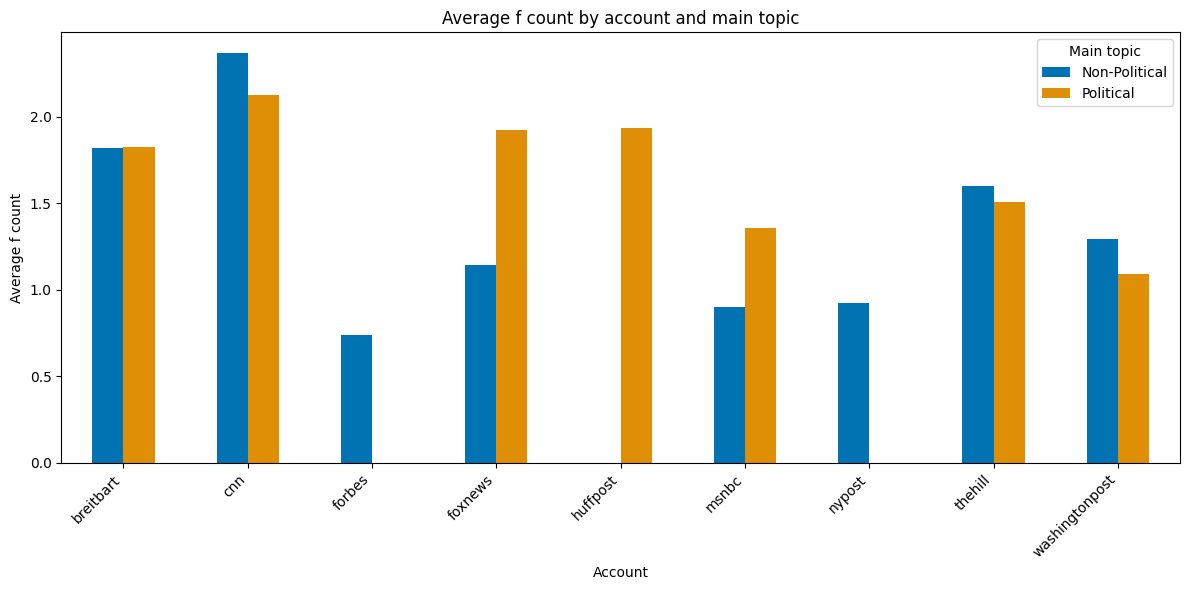

In [41]:
df2 = reg_news_df.copy()
df2["fcount_no_rank"] = pd.to_numeric(df2["fcount_no_rank"], errors="coerce")
df2["ftrials_no_rank"] = pd.to_numeric(df2["ftrials_no_rank"], errors="coerce")

df2 = df2[
    df2["fcount_no_rank"].ne(-1) &
    df2["ftrials_no_rank"].ne(-1)
].copy()

df2["rate"] = df2["fcount_no_rank"] / df2["ftrials_no_rank"]

df2 = df2[df2["main_topic"].isin(["Political", "Non-Political"])].copy()

avg_by_combo = (
    df2.groupby(["account", "main_topic"], as_index=False)
       .agg(
           n=("urlid", "count"),
           avg_fcount=("fcount_no_rank", "mean"),
           avg_ftrials=("ftrials_no_rank", "mean"),
           avg_rate=("rate", "mean"),
       )
       .sort_values(["account", "main_topic"])
)

# value_col = "fcount_no_rank" 
# for acct, g in df2.groupby("account"):
#     gp = g[g["main_topic"] == "Political"][value_col].dropna().to_numpy()
#     gnp = g[g["main_topic"] == "Non-Political"][value_col].dropna().to_numpy()

#     if len(gp) == 0 and len(gnp) == 0:
#         continue

#     allx = np.concatenate([gp, gnp]) if (len(gp) and len(gnp)) else (gp if len(gp) else gnp)

#     xmin, xmax = np.nanmin(allx), np.nanmax(allx)
#     if np.isfinite(xmin) and np.isfinite(xmax) and xmin != xmax:
#         bins = np.linspace(xmin, xmax, 21)
#     else:
#         bins = 10

#     fig, ax = plt.subplots(figsize=(7, 4))

#     if len(gp):
#         ax.hist(gp, bins=bins, density=True, histtype="bar", linewidth=2, label=f"Political (n={len(gp)})", stacked=True)
#     if len(gnp):
#         ax.hist(gnp, bins=bins, density=True, histtype="bar", linewidth=2, label=f"Non-Political (n={len(gnp)})", stacked=True)

#     ax.set_title(f"{acct} — {value_col} distribution")
#     ax.set_xlabel(value_col)
#     ax.set_ylabel("Density")
#     ax.legend()
#     fig.tight_layout()
#     plt.show()

display(avg_by_combo)

pivot = avg_by_combo.pivot(index="account", columns="main_topic", values="avg_fcount").sort_index()

ax = pivot.plot(kind="bar", figsize=(12, 6))
ax.set_title("Average f count by account and main topic")
ax.set_xlabel("Account")
ax.set_ylabel("Average f count")
ax.legend(title="Main topic")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()